# Part A: Import Library and Dataset(Shared)


In [ ]:
%pip -q install kagglehub



In [ ]:
from pathlib import Path
import re
import warnings

import cv2
import joblib
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image, ImageOps, UnidentifiedImageError
from tqdm.auto import tqdm

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

RANDOM_SEED = 42
IMAGE_SIZE = 256
GRABCUT_ITERATIONS = 6
SUPPORTED_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

OUTPUT_DIR = Path("/content/banana_svm_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

np.random.seed(RANDOM_SEED)
sns.set_theme(style="whitegrid")



## 1. Download and inspect the dataset



In [ ]:
DATASET_ROOT = Path(kagglehub.dataset_download(
    "iamchaarles/banalyzer-banana-ripeness-classification-dataset"
))
print("Dataset location:", DATASET_ROOT)

# Show a compact directory preview without printing all image names.
directories = sorted(p for p in DATASET_ROOT.rglob("*") if p.is_dir())
for directory in directories[:40]:
    print(" -", directory.relative_to(DATASET_ROOT))
if len(directories) > 40:
    print(f" ... and {len(directories) - 40} more directories")



Using Colab cache for faster access to the 'banalyzer-banana-ripeness-classification-dataset' dataset.
Dataset location: /kaggle/input/banalyzer-banana-ripeness-classification-dataset
 - banana_data
 - banana_data/data
 - banana_data/data/test
 - banana_data/data/test/overripe
 - banana_data/data/test/ripe
 - banana_data/data/test/rotten
 - banana_data/data/test/unripe
 - banana_data/data/train
 - banana_data/data/train/overripe
 - banana_data/data/train/ripe
 - banana_data/data/train/rotten
 - banana_data/data/train/unripe


The label and split are inferred from directory names, so the notebook remains
usable if Kaggle adds one extra wrapper directory around `banana_data`.



In [ ]:
CLASS_ALIASES = {
    "unripe": "Unripe",
    "ripe": "Ripe",
    "overripe": "Overripe",
    "rotten": "Rotten",
}

SPLIT_ALIASES = {
    "train": "train",
    "training": "train",
    "val": "validation",
    "valid": "validation",
    "validation": "validation",
    "test": "test",
    "testing": "test",
}


def compact_token(value: str) -> str:
    """Lowercase a folder name and remove spaces/punctuation."""
    return re.sub(r"[^a-z0-9]+", "", value.lower())


def infer_label(path: Path):
    for part in reversed(path.parts[:-1]):
        token = compact_token(part)
        if token in CLASS_ALIASES:
            return CLASS_ALIASES[token]
    return None


def infer_split(path: Path) -> str:
    for part in reversed(path.parts[:-1]):
        token = compact_token(part)
        if token in SPLIT_ALIASES:
            return SPLIT_ALIASES[token]
    return "unspecified"


def build_image_index(root: Path) -> pd.DataFrame:
    rows = []
    skipped_without_label = 0

    for path in root.rglob("*"):
        if not path.is_file() or path.suffix.lower() not in SUPPORTED_EXTENSIONS:
            continue
        label = infer_label(path)
        if label is None:
            skipped_without_label += 1
            continue
        rows.append({"path": str(path), "label": label, "split": infer_split(path)})

    frame = pd.DataFrame(rows).drop_duplicates(subset="path").reset_index(drop=True)
    if frame.empty:
        raise RuntimeError(
            "No labelled images were found. Inspect the printed folders and update "
            "CLASS_ALIASES if the class names differ."
        )

    print(f"Indexed {len(frame):,} labelled images.")
    if skipped_without_label:
        print(f"Ignored {skipped_without_label} image(s) outside recognised class folders.")
    display(pd.crosstab(frame["label"], frame["split"], margins=True))
    return frame

image_index = build_image_index(DATASET_ROOT)


Indexed 1,200 labelled images.


split,test,train,All
label,,,
Overripe,50,250,300
Ripe,50,250,300
Rotten,50,250,300
Unripe,50,250,300
All,200,1000,1200


In [ ]:
# Create the shared training and testing dataframes
LABELS = ["Unripe", "Ripe", "Overripe", "Rotten"]

train_df = (
    image_index[image_index["split"].str.lower() == "train"]
    .copy()
    .reset_index(drop=True)
)

test_df = (
    image_index[image_index["split"].str.lower() == "test"]
    .copy()
    .reset_index(drop=True)
)

if train_df.empty:
    raise RuntimeError("No training images were found in image_index.")

if test_df.empty:
    raise RuntimeError("No testing images were found in image_index.")

print("Training images:", len(train_df))
print("Testing images :", len(test_df))

display(pd.DataFrame({
    "Train": train_df["label"].value_counts(),
    "Test": test_df["label"].value_counts()
}).fillna(0).astype(int).reindex(LABELS))

Training images: 1000
Testing images : 200


,Train,Test
label,,
Unripe,250,50
Ripe,250,50
Overripe,250,50
Rotten,250,50


# Part B: Original Baseline(Shared)

**Baseline flow:**  
`RGB image → Resize 64×64 → Normalise RGB pixels → StandardScaler → RBF-SVM → Prediction`

No Gaussian, Watershed or GrabCut is used in the baseline.

In [ ]:
# PART B1 — ORIGINAL RGB BASELINE: FEATURES + TRAIN SVM

SVM_IMAGE_SIZE = (64, 64)

def load_rgb(path):
    bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if bgr is None:
        raise ValueError(f"Cannot read image: {path}")
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

def rgb_pixel_vector(rgb):
    resized = cv2.resize(rgb, SVM_IMAGE_SIZE, interpolation=cv2.INTER_AREA)
    return (resized.astype(np.float32) / 255.0).reshape(-1)

def build_matrix(frame, extractor, name):
    features = []
    for i, path in enumerate(frame["path"]):
        features.append(extractor(path))
        if (i + 1) % 100 == 0 or i + 1 == len(frame):
            print(f"{name}: {i + 1}/{len(frame)}")
    return np.stack(features)

def baseline_feature(path):
    return rgb_pixel_vector(load_rgb(path))

SVM_PARAM_GRID = {
    "svm__C": [1, 10, 50, 100],
    "svm__gamma": ["scale", 0.0001, 0.001],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

def make_search():
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="rbf", probability=False, random_state=RANDOM_SEED)),
    ])
    return GridSearchCV(
        pipe, SVM_PARAM_GRID, scoring="accuracy",
        cv=cv, n_jobs=-1, refit=True
    )

def make_final_svm(C, gamma):
    return Pipeline([
        ("scaler", StandardScaler()),
        ("svm", SVC(
            kernel="rbf",
            C=C,
            gamma=gamma,
            probability=True,
            random_state=RANDOM_SEED,
        )),
    ])

def predict_with_confidence(model, vector):
    row = vector.reshape(1, -1)
    pred = model.predict(row)[0]
    probs = model.predict_proba(row)[0]
    classes = list(model.named_steps["svm"].classes_)
    confidence = float(probs[classes.index(pred)])
    return pred, confidence, probs, classes

X_train_baseline = build_matrix(train_df, baseline_feature, "Baseline train")
X_test_baseline = build_matrix(test_df, baseline_feature, "Baseline test")
y_train = train_df["label"].to_numpy()
y_test = test_df["label"].to_numpy()

baseline_search = make_search()
baseline_search.fit(X_train_baseline, y_train)

BASELINE_C = baseline_search.best_params_["svm__C"]
BASELINE_GAMMA = baseline_search.best_params_["svm__gamma"]

baseline_model = make_final_svm(BASELINE_C, BASELINE_GAMMA)
baseline_model.fit(X_train_baseline, y_train)

print("Baseline SVM trained")
print("Best C:", BASELINE_C)
print("Best gamma:", BASELINE_GAMMA)
print(f"Training CV accuracy: {baseline_search.best_score_ * 100:.2f}%")

Baseline train: 100/1000
Baseline train: 200/1000
Baseline train: 300/1000
Baseline train: 400/1000
Baseline train: 500/1000
Baseline train: 600/1000
Baseline train: 700/1000
Baseline train: 800/1000
Baseline train: 900/1000
Baseline train: 1000/1000
Baseline test: 100/200
Baseline test: 200/200
Baseline SVM trained
Best C: 10
Best gamma: 0.0001
Training CV accuracy: 92.00%


Baseline Test Accuracy : 83.50%
Baseline Macro F1      : 83.44%

Classification Report:

              precision    recall  f1-score   support

      Unripe       0.94      0.66      0.78        50
        Ripe       0.67      0.86      0.75        50
    Overripe       0.89      0.82      0.85        50
      Rotten       0.91      1.00      0.95        50

    accuracy                           0.83       200
   macro avg       0.85      0.83      0.83       200
weighted avg       0.85      0.83      0.83       200



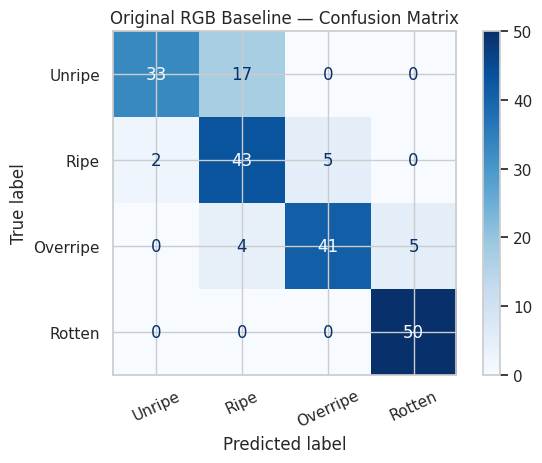

In [ ]:
# PART B2 — ORIGINAL RGB BASELINE RESULT
baseline_pred = baseline_model.predict(X_test_baseline)
baseline_accuracy = accuracy_score(y_test, baseline_pred)
baseline_macro_f1 = f1_score(y_test, baseline_pred, average="macro")

print(f"Baseline Test Accuracy : {baseline_accuracy * 100:.2f}%")
print(f"Baseline Macro F1      : {baseline_macro_f1 * 100:.2f}%")
print("\nClassification Report:\n")
print(classification_report(y_test, baseline_pred, labels=LABELS, zero_division=0))

cm = confusion_matrix(y_test, baseline_pred, labels=LABELS)
disp = ConfusionMatrixDisplay(cm, display_labels=LABELS)
disp.plot(cmap="Blues", values_format="d", colorbar=True)
plt.title("Original RGB Baseline — Confusion Matrix")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

# Part C — Pre-processing with validation, resizing, hybrid GrabCut, and fruit mask(Shared)

HSV and CIELAB are used to initialise confident foreground/background regions.
GrabCut runs on a BGR representation rather than directly on HSV. For
predominantly black backgrounds, luminance contrast is enhanced only inside
the segmentation branch, dark foreground candidates are relaxed, and bright
neutral plates/text are removed before morphology. Feature extraction continues
to use the unchanged resized image.
If those strategies still fail, a centre-prior GrabCut pass handles complex
foliage and infographic-style images; wide edge banners are then discarded.



In [ ]:
def load_validate_resize(path, image_size=IMAGE_SIZE):
    """Validate with Pillow, fix EXIF orientation, convert to BGR, and resize."""
    try:
        with Image.open(path) as pil_image:
            pil_image = ImageOps.exif_transpose(pil_image).convert("RGB")
            width, height = pil_image.size
            if min(width, height) < 32:
                raise ValueError(f"image is too small: {width}x{height}")
            rgb = np.asarray(pil_image)
    except (UnidentifiedImageError, OSError, ValueError) as exc:
        raise ValueError(f"invalid image {path}: {exc}") from exc

    bgr = cv2.cvtColor(rgb, cv2.COLOR_RGB2BGR)
    interpolation = cv2.INTER_AREA if max(width, height) > image_size else cv2.INTER_CUBIC
    return cv2.resize(bgr, (image_size, image_size), interpolation=interpolation)

# relative_threshold=0.03: components must have an area of at least 3% of the largest component.
#count: total number of labels, including the background.
#labels: an image showing the component ID assigned to every pixel.
#stats: measurements for every component, including area and bounding box.
#_: the component centroids, which are not required here.
# If count is 1, only the background component exists. This means no foreground region was detected.
# The original mask is returned without further processing.
def remove_small_components(mask, relative_threshold=0.03):
    """Keep components that are large relative to the main fruit component."""
    count, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    if count <= 1:
        return mask

    component_areas = stats[1:, cv2.CC_STAT_AREA]
    largest_area = int(component_areas.max())
    minimum_area = max(32, int(largest_area * relative_threshold))
    clean = np.zeros_like(mask)
    for component_id in range(1, count):
        if stats[component_id, cv2.CC_STAT_AREA] >= minimum_area:
            clean[labels == component_id] = 255
    return clean

# In fruit segmentation, the image background commonly extends to the image borders, whereas the banana is usually located near the centre.
# Therefore, regions connected to an image edge are often likely to be background.
def border_connected_regions(candidate):
    """Return candidate regions connected to at least one image edge."""
    count, labels = cv2.connectedComponents(candidate.astype(np.uint8), connectivity=8)
    if count <= 1:
        return np.zeros_like(candidate, dtype=bool)

    edge_labels = np.unique(np.concatenate([
        labels[0, :], labels[-1, :], labels[:, 0], labels[:, -1]
    ]))
    edge_labels = edge_labels[edge_labels != 0]
    return np.isin(labels, edge_labels)

# Threhold = 105. The maximum median border brightness for the image to be considered dark.
def has_dark_background(image_bgr, threshold=105):
    """Detect images whose outer border is predominantly dark."""
    hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV)
    height, width = image_bgr.shape[:2]
    border_width = max(3, int(round(min(height, width) * 0.04)))
    border_value = np.concatenate([
        hsv[:border_width, :, 2].ravel(),
        hsv[-border_width:, :, 2].ravel(),
        hsv[:, :border_width, 2].ravel(),
        hsv[:, -border_width:, 2].ravel(),
    ])
    return float(np.median(border_value)) < threshold

# This function prepares an image for GrabCut. It applies CLAHE contrast enhancement only when the image has a dark background.
# Dark rotten bananas may have colours similar to a black background. This can make it difficult for GrabCut to distinguish the banana boundary.
def prepare_grabcut_input(image_bgr):
    """Apply mild luminance CLAHE only for dark-background segmentation."""
    if not has_dark_background(image_bgr):
        return image_bgr

    lab = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2LAB)
    lightness, a_channel, b_channel = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    enhanced_lightness = clahe.apply(lightness)
    enhanced_lab = cv2.merge((enhanced_lightness, a_channel, b_channel))
    return cv2.cvtColor(enhanced_lab, cv2.COLOR_LAB2BGR)

# Applying histogram equalization separately to B, G and R channels could change the banana’s colour balance.
# Enhancing only the Lab lightness channel improves contrast while preserving the original a and b colour information as much as possible.
# The original resized image can still be used for final feature extraction. The enhanced image is primarily used to help GrabCut generate a better mask.
def build_grabcut_seed_mask(image_bgr):
    """Create adaptive GrabCut seeds from HSV and CIELAB border statistics."""
    height, width = image_bgr.shape[:2]
    hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV).astype(np.float32)
    lab = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2LAB).astype(np.float32)

    saturation = hsv[..., 1]
    value = hsv[..., 2]
    lightness = lab[..., 0]
    a_star = lab[..., 1] - 128.0
    b_star = lab[..., 2] - 128.0
    chroma = np.sqrt(a_star ** 2 + b_star ** 2)

    border_width = max(3, int(round(min(height, width) * 0.04)))
    border_lab = np.concatenate([
        lab[:border_width].reshape(-1, 3),
        lab[-border_width:].reshape(-1, 3),
        lab[:, :border_width].reshape(-1, 3),
        lab[:, -border_width:].reshape(-1, 3),
    ])
    background_colour = np.median(border_lab, axis=0)
    colour_distance = np.linalg.norm(lab - background_colour, axis=2)
    border_distance = np.linalg.norm(border_lab - background_colour, axis=1)
    distance_threshold = max(12.0, float(np.percentile(border_distance, 97)) + 5.0)

    # Background candidates must resemble the border and remain connected to it.
    # This avoids cutting white highlights that occur inside the banana itself.
    neutral_bright = (
        (saturation < 38)
        & (value > 175)
        & (lightness > 170)
        & (chroma < 16)
    )
    background_candidate = (
        (colour_distance < 0.80 * distance_threshold) | neutral_bright
    )
    confident_background = border_connected_regions(background_candidate)

    # Keep saturated yellow/green pixels, dark rotten areas, and pixels that are
    # perceptually far from the border background as foreground candidates.
    # Border-similar pixels remain probable background, not definite background;
    # otherwise black bananas on a black background cannot be recovered.
    likely_foreground = (
        (colour_distance > distance_threshold)
        | ((saturation > 48) & (value > 28))
        | ((value < 125) & (colour_distance > 8))
        | (chroma > 18)
    )

    dark_background = has_dark_background(image_bgr)
    if dark_background:
        # Expand reliable colour/brightness anchors into nearby dark regions.
        # GrabCut will make the final edge decision using the enhanced BGR image.
        envelope_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (25, 25))
        anchor_envelope = cv2.dilate(
            likely_foreground.astype(np.uint8), envelope_kernel, iterations=2
        ).astype(bool)
        interior = np.zeros((height, width), dtype=bool)
        interior_margin = max(3, int(round(min(height, width) * 0.025)))
        interior[
            interior_margin:height - interior_margin,
            interior_margin:width - interior_margin,
        ] = True
        relaxed_dark_foreground = (
            interior
            & anchor_envelope
            & (value < 155)
            & (colour_distance > max(4.0, 0.35 * distance_threshold))
        )
        likely_foreground |= relaxed_dark_foreground
    else:
        # Preserve the stronger background exclusion that works well for the
        # dataset's white and light-grey backgrounds.
        likely_foreground &= ~confident_background

    strong_foreground = (
        (colour_distance > distance_threshold)
        | ((saturation > 48) & (value > 28))
        | (chroma > 18)
    )
    if not dark_background:
        strong_foreground &= ~confident_background

    seed_mask = np.full((height, width), cv2.GC_PR_BGD, dtype=np.uint8)
    seed_mask[confident_background] = cv2.GC_PR_BGD
    seed_mask[likely_foreground] = cv2.GC_PR_FGD

    # Eroded colour candidates provide high-confidence foreground cores.
    core_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    foreground_core = cv2.erode(
        strong_foreground.astype(np.uint8), core_kernel, iterations=2
    ).astype(bool)
    seed_mask[foreground_core] = cv2.GC_FGD

    # A narrow definite-background frame stabilises GrabCut without removing
    # as much edge content as rectangle initialisation.
    frame_width = max(1, int(round(min(height, width) * 0.008)))
    seed_mask[:frame_width, :] = cv2.GC_BGD
    seed_mask[-frame_width:, :] = cv2.GC_BGD
    seed_mask[:, :frame_width] = cv2.GC_BGD
    seed_mask[:, -frame_width:] = cv2.GC_BGD

    foreground_seed_count = np.count_nonzero(
        (seed_mask == cv2.GC_FGD) | (seed_mask == cv2.GC_PR_FGD)
    )
    if foreground_seed_count < 64:
        raise ValueError("HSV/Lab initialisation found too few foreground seeds")
    return seed_mask


# The adaptive_border_fallback() function creates an alternative fruit mask when GrabCut fails or produces an excessively small mask.
# It assumes that most pixels along the image border represent the background.
# It estimates the background colour from those border pixels and then selects image pixels whose CIE L*a*b* colour differs sufficiently from the estimated background.
# A fixed colour-distance threshold may work for one background but fail for another.
# This function measures the actual variation among the border pixels and adjusts its threshold accordingly:
# - Uniform background → lower threshold
# - Textured or variable background → higher threshold
def adaptive_border_fallback(image_bgr):
    """Fallback mask based on adaptive CIELAB distance from the image border."""
    lab = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2LAB).astype(np.float32)
    border_width = max(3, int(round(min(image_bgr.shape[:2]) * 0.04)))
    border = np.concatenate([
        lab[:border_width].reshape(-1, 3),
        lab[-border_width:].reshape(-1, 3),
        lab[:, :border_width].reshape(-1, 3),
        lab[:, -border_width:].reshape(-1, 3),
    ])
    background_colour = np.median(border, axis=0)
    colour_distance = np.linalg.norm(lab - background_colour, axis=2)
    border_distance = np.linalg.norm(border - background_colour, axis=1)
    adaptive_threshold = max(12.0, float(np.percentile(border_distance, 97)) + 5.0)
    mask = np.where(colour_distance > adaptive_threshold, 255, 0).astype(np.uint8)
    return mask

# The function removes banner-like foreground components from a binary mask.
# It targets wide and short regions connected to the top or bottom of the image, such as titles, labels, black strips or watermarks.
def remove_edge_banner_components(mask):
    """Remove wide, shallow components attached to the top or bottom image edge."""
    height, width = mask.shape
    count, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    cleaned = mask.copy()

    for component_id in range(1, count):
        x = stats[component_id, cv2.CC_STAT_LEFT]
        y = stats[component_id, cv2.CC_STAT_TOP]
        component_width = stats[component_id, cv2.CC_STAT_WIDTH]
        component_height = stats[component_id, cv2.CC_STAT_HEIGHT]
# Checks whether the component has a banner-like shape.
        wide_and_shallow = (
            component_width >= 0.55 * width
            and component_height <= 0.22 * height
        )
        near_horizontal_edge = (
            y <= 0.06 * height
            or (y + component_height) >= 0.94 * height
        )
        if wide_and_shallow and near_horizontal_edge:
            cleaned[labels == component_id] = 0

    return cleaned


# improves a binary fruit mask after segmentation.
# It removes banner-like regions, small noise, thin connections and small holes while preserving the main banana region.
def clean_fruit_mask(mask):
    """Apply conservative morphology and remove isolated logos/noise."""
    opening_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    closing_kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask = remove_edge_banner_components(mask)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, opening_kernel, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, closing_kernel, iterations=2)
    return remove_small_components(mask, relative_threshold=0.03)


# removes bright, colourless objects—such as white plates, labels and text—from a fruit mask when the image has a dark background.
def suppress_dark_scene_artifacts(mask, image_bgr):
    """Remove bright neutral plates/text when the true scene background is dark."""
    if not has_dark_background(image_bgr):
        return mask

    hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV).astype(np.float32)
    lab = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2LAB).astype(np.float32)
    saturation = hsv[..., 1]
    value = hsv[..., 2]
    a_star = lab[..., 1] - 128.0
    b_star = lab[..., 2] - 128.0
    chroma = np.sqrt(a_star ** 2 + b_star ** 2)

    bright_neutral = (saturation < 42) & (value > 165) & (chroma < 18)
    cleaned = mask.copy()
    cleaned[bright_neutral] = 0

    # Do not erase the only detected region. This can happen when GrabCut finds
    # the plate but has not yet recovered the similarly dark banana.
    minimum_remaining = max(64, int(mask.size * 0.005))
    if np.count_nonzero(cleaned) >= minimum_remaining:
        return cleaned
    return mask

# The seed_foreground_recovery() function creates a fallback fruit mask directly from the foreground seeds prepared for GrabCut.
# It is useful when the final GrabCut mask is empty or too small.
# Instead of discarding the image immediately, the function reuses pixels that were previously labelled as definite or probable foreground.
def seed_foreground_recovery(image_bgr):
    """Convert adaptive probable/definite foreground seeds into a recovery mask."""
    seed_mask = build_grabcut_seed_mask(image_bgr)
    recovery = np.where(
        (seed_mask == cv2.GC_FGD) | (seed_mask == cv2.GC_PR_FGD), 255, 0
    ).astype(np.uint8)
    recovery = suppress_dark_scene_artifacts(recovery, image_bgr)
    return clean_fruit_mask(recovery)


# The central_overlap_count() function counts how many foreground-mask pixels lie inside a broad elliptical region near the centre of the image.
# It is used to determine whether a detected component is likely to represent the banana.
# In this dataset, bananas are generally located near the centre, whereas logos, banners and noise are often positioned near the edges.
def central_overlap_count(mask):
    """Count foreground pixels inside a broad, dataset-appropriate centre prior."""
    height, width = mask.shape
    centre_region = np.zeros((height, width), dtype=np.uint8)
    cv2.ellipse(
        centre_region,
        (width // 2, int(round(height * 0.52))),
        (max(8, int(width * 0.43)), max(8, int(height * 0.43))),
        0,
        0,
        360,
        1,
        -1,
    )
    return int(np.count_nonzero((mask > 0) & (centre_region > 0)))

# The mask_is_usable() function checks whether a generated mask is suitable for fruit-feature extraction.
# A mask is accepted only when:
# 1. Its foreground area is neither too small nor too large.
# 2. A meaningful part of its foreground overlaps the central image region.
def mask_is_usable(mask, minimum_fraction=0.005, maximum_fraction=0.95):
    foreground_count = int(np.count_nonzero(mask))
    fraction = foreground_count / mask.size
    if not minimum_fraction <= fraction <= maximum_fraction:
        return False

    # Reject masks containing only a corner logo or watermark. A valid fruit mask
    # must have at least a small but meaningful presence in the broad centre ROI.
    required_central_pixels = max(32, int(0.05 * foreground_count))
    return central_overlap_count(mask) >= required_central_pixels


# The rectangle_grabcut_mask() function applies conventional GrabCut using a rectangular initialization.
# It is used as a fallback when adaptive foreground and background seeding does not produce a usable fruit mask.
def rectangle_grabcut_mask(image_bgr, grabcut_iterations):
    """Conventional rectangle initialisation used only if adaptive seeding fails."""
    height, width = image_bgr.shape[:2]
    margin = max(2, int(round(min(height, width) * 0.015)))
    rectangle = (margin, margin, width - 2 * margin, height - 2 * margin)
    gc_mask = np.zeros((height, width), np.uint8)
    bg_model = np.zeros((1, 65), np.float64)
    fg_model = np.zeros((1, 65), np.float64)
    cv2.grabCut(
        image_bgr,
        gc_mask,
        rectangle,
        bg_model,
        fg_model,
        grabcut_iterations,
        cv2.GC_INIT_WITH_RECT,
    )
    return np.where(
        (gc_mask == cv2.GC_FGD) | (gc_mask == cv2.GC_PR_FGD), 255, 0
    ).astype(np.uint8)


# The central_prior_grabcut_mask() function is a final GrabCut recovery method for difficult images. It assumes that the banana is positioned near the centre of the image.
# Unlike rectangle initialization, this function supplies GrabCut with a four-label mask containing:
# - Definite background
# - Probable background
# - Definite foreground
# - Probable foreground
def central_prior_grabcut_mask(image_bgr, grabcut_iterations):
    """Final recovery for complex scenes where the fruit is near the image centre."""
    height, width = image_bgr.shape[:2]
    gc_mask = np.full((height, width), cv2.GC_PR_BGD, dtype=np.uint8)

    centre = (width // 2, int(round(height * 0.53)))
    probable_axes = (
        max(8, int(round(width * 0.38))),
        max(8, int(round(height * 0.42))),
    )
    core_axes = (
        max(4, int(round(width * 0.16))),
        max(4, int(round(height * 0.20))),
    )
    cv2.ellipse(gc_mask, centre, probable_axes, 0, 0, 360, cv2.GC_PR_FGD, -1)
    cv2.ellipse(gc_mask, centre, core_axes, 0, 0, 360, cv2.GC_FGD, -1)

    frame_width = max(2, int(round(min(height, width) * 0.015)))
    gc_mask[:frame_width, :] = cv2.GC_BGD
    gc_mask[-frame_width:, :] = cv2.GC_BGD
    gc_mask[:, :frame_width] = cv2.GC_BGD
    gc_mask[:, -frame_width:] = cv2.GC_BGD

    bg_model = np.zeros((1, 65), np.float64)
    fg_model = np.zeros((1, 65), np.float64)
    cv2.grabCut(
        image_bgr,
        gc_mask,
        None,
        bg_model,
        fg_model,
        grabcut_iterations,
        cv2.GC_INIT_WITH_MASK,
    )
    return np.where(
        (gc_mask == cv2.GC_FGD) | (gc_mask == cv2.GC_PR_FGD), 255, 0
    ).astype(np.uint8)

# The generate_fruit_mask() function is the main controller for the entire fruit-segmentation process.
# It tries the preferred adaptive GrabCut method first, cleans and validates its result, and then attempts several recovery methods if necessary.
def generate_fruit_mask(image_bgr, grabcut_iterations=GRABCUT_ITERATIONS):
    """Run HSV/Lab-seeded GrabCut on BGR, then clean and validate the mask."""
    grabcut_input = prepare_grabcut_input(image_bgr)
    bg_model = np.zeros((1, 65), np.float64)
    fg_model = np.zeros((1, 65), np.float64)
    raw_grabcut_mask = None

    try:
        gc_mask = build_grabcut_seed_mask(image_bgr)
        cv2.grabCut(
            grabcut_input,
            gc_mask,
            None,
            bg_model,
            fg_model,
            grabcut_iterations,
            cv2.GC_INIT_WITH_MASK,
        )
        mask = np.where(
            (gc_mask == cv2.GC_FGD) | (gc_mask == cv2.GC_PR_FGD), 255, 0
        ).astype(np.uint8)
        raw_grabcut_mask = mask.copy()
    except (cv2.error, ValueError):
        try:
            mask = rectangle_grabcut_mask(grabcut_input, grabcut_iterations)
            raw_grabcut_mask = mask.copy()
        except cv2.error:
            mask = adaptive_border_fallback(image_bgr)

    mask = suppress_dark_scene_artifacts(mask, image_bgr)
    mask = clean_fruit_mask(mask)

    if not mask_is_usable(mask):
        recovery_candidates = []

        if has_dark_background(image_bgr):
            try:
                recovery_candidates.append(seed_foreground_recovery(image_bgr))
            except (cv2.error, ValueError):
                pass

        # Handles highly textured foliage and infographic/title-banner images.
        try:
            central_recovery = central_prior_grabcut_mask(
                grabcut_input, grabcut_iterations
            )
            central_recovery = suppress_dark_scene_artifacts(
                central_recovery, image_bgr
            )
            recovery_candidates.append(clean_fruit_mask(central_recovery))
        except cv2.error:
            pass

        border_recovery = adaptive_border_fallback(image_bgr)
        border_recovery = suppress_dark_scene_artifacts(border_recovery, image_bgr)
        recovery_candidates.append(clean_fruit_mask(border_recovery))

        # The unsuppressed GrabCut result is safer than aborting if plate/text
        # suppression was too aggressive for an unusual image.
        if raw_grabcut_mask is not None:
            recovery_candidates.append(clean_fruit_mask(raw_grabcut_mask))

        usable_candidates = [candidate for candidate in recovery_candidates if mask_is_usable(candidate)]
        if usable_candidates:
            mask = usable_candidates[0]
        else:
            nonempty_candidates = [
                candidate for candidate in recovery_candidates
                if np.count_nonzero(candidate) >= 64
            ]
            if nonempty_candidates:
                mask = max(
                    nonempty_candidates,
                    key=lambda candidate: (
                        central_overlap_count(candidate),
                        np.count_nonzero(candidate),
                    ),
                )

    if np.count_nonzero(mask) < 64:
        raise ValueError(
            "all GrabCut and adaptive recovery strategies produced an empty mask"
        )
    return mask

# The preprocess_image() function combines the main Part A preprocessing operations into one function.
# It loads and resizes the image, generates the fruit mask, and applies the mask to extract the banana foreground.
def preprocess_image(path):
    resized = load_validate_resize(path)
    mask = generate_fruit_mask(resized)
    foreground = cv2.bitwise_and(resized, resized, mask=mask)
    return resized, mask, foreground

# Preserve the real shared preprocessing function
shared_preprocess_image = preprocess_image

# ============================================================
# SHARED PRE-PROCESSING
# ============================================================

SHARED_IMAGE_SIZE = 256


def shared_preprocess_image(path):

    resized_bgr = load_validate_resize(
        path,
        image_size=SHARED_IMAGE_SIZE
    )

    shared_mask = generate_fruit_mask(
        resized_bgr
    )

    shared_foreground_bgr = cv2.bitwise_and(
        resized_bgr,
        resized_bgr,
        mask=shared_mask
    )

    return (
        resized_bgr,
        shared_mask,
        shared_foreground_bgr
    )


Visual check: one example per class. The mask should cover the banana rather
than the background. The current configuration uses 6 GrabCut iterations.



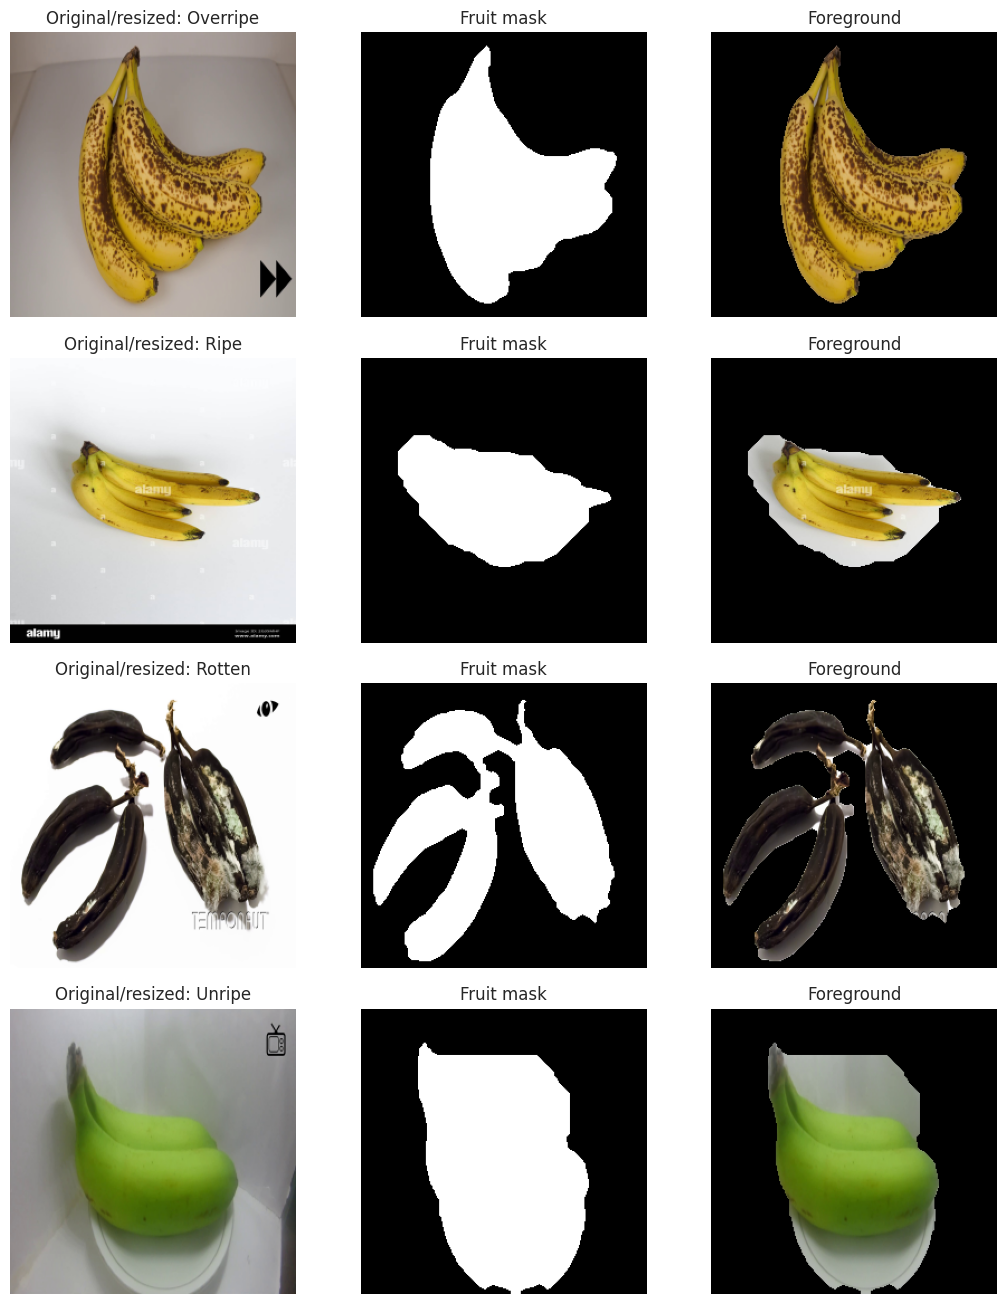

In [ ]:
sample_rows = (
    image_index.groupby("label", group_keys=False)
    .sample(n=1, random_state=RANDOM_SEED)
    .sort_values("label")
)

fig, axes = plt.subplots(len(sample_rows), 3, figsize=(11, 3.3 * len(sample_rows)))
if len(sample_rows) == 1:
    axes = np.expand_dims(axes, axis=0)

for row_axes, row in zip(axes, sample_rows.itertuples(index=False)):
    try:
        resized, mask, foreground = preprocess_image(row.path)
        mask_title = "Fruit mask"
    except Exception as exc:
        warnings.warn(f"Could not segment preview image {row.path}: {exc}")
        resized = load_validate_resize(row.path)
        mask = np.zeros(resized.shape[:2], dtype=np.uint8)
        foreground = np.zeros_like(resized)
        mask_title = "Segmentation failed (logged)"
    panels = [
        cv2.cvtColor(resized, cv2.COLOR_BGR2RGB),
        mask,
        cv2.cvtColor(foreground, cv2.COLOR_BGR2RGB),
    ]
    titles = [f"Original/resized: {row.label}", mask_title, "Foreground"]
    for ax, panel, title in zip(row_axes, panels, titles):
        ax.imshow(panel, cmap="gray" if panel.ndim == 2 else None)
        ax.set_title(title)
        ax.axis("off")

plt.tight_layout()
plt.show()



# JIN

## 3. Part B — adaptive HSV + L*a*b* feature extraction

The GrabCut mask defines the fruit. Within that mask, an adaptive per-image
rule removes low-colour highlights/background remnants while retaining dark
pixels (important for overripe and rotten bananas). Fixed histograms then keep
feature meanings comparable between images.



In [ ]:
# The robust_statistics() function converts a variable-length collection of pixel values into seven fixed numerical features.
# For example, a fruit mask may contain 20,000 saturation values.
# The SVM cannot conveniently receive a different number of pixels for every image, so this function summarizes those values using mean, standard deviation and percentiles.
# values contains the numerical pixel measurements to analyse, while prefix identifies which colour channel those measurements came from.
def robust_statistics(values, prefix):
    values = np.asarray(values, dtype=np.float32)
    q10, q25, q50, q75, q90 = np.percentile(values, [10, 25, 50, 75, 90])
    return {
        f"{prefix}_mean": float(np.mean(values)),
        f"{prefix}_std": float(np.std(values)),
        f"{prefix}_p10": float(q10),
        f"{prefix}_p25": float(q25),
        f"{prefix}_median": float(q50),
        f"{prefix}_p75": float(q75),
        f"{prefix}_p90": float(q90),
    }


# The normalised_histogram() function summarizes the distribution of colour-channel values using a fixed number of bins.
# It converts thousands of fruit-pixel values into a consistent set of numerical features for the SVM.
def normalised_histogram(values, bins, value_range, prefix, weights=None):
    histogram, _ = np.histogram(values, bins=bins, range=value_range, weights=weights)
    histogram = histogram.astype(np.float64)
    histogram /= histogram.sum() + 1e-12
    return {f"{prefix}_hist_{i:02d}": float(value) for i, value in enumerate(histogram)}

# The adaptive_hsv_lab_maps() function converts a segmented banana image into HSV and CIE L*a*b* colour representations.
# It then creates an informative-pixel mask that retains pixels with useful colour or dark deterioration information.
# It does not directly create the final 121 features. Instead, it prepares the colour channels and selected pixels used by extract_adaptive_hsv_lab_features().
def adaptive_hsv_lab_maps(image_bgr, mask):
    """Return HSV/Lab channels and the adaptive informative-pixel mask."""
    hsv = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2HSV).astype(np.float32)
    lab8 = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2LAB).astype(np.float32)

    # OpenCV HSV: H is [0, 179]. Convert S and V to [0, 1].
    hue = hsv[..., 0]
    saturation = hsv[..., 1] / 255.0
    value = hsv[..., 2] / 255.0

    # Convert OpenCV's encoded Lab values to approximately standard CIELAB units.
    lightness = lab8[..., 0] * (100.0 / 255.0)
    a_star = lab8[..., 1] - 128.0
    b_star = lab8[..., 2] - 128.0
    chroma = np.sqrt(a_star ** 2 + b_star ** 2)

    fruit = mask > 0
    if np.count_nonzero(fruit) < 64:
        raise ValueError("fruit mask is too small for HSV/Lab feature extraction")

    fruit_s = saturation[fruit]
    fruit_c = chroma[fruit]

    # Adaptive confidence thresholds are estimated independently for each image.
    # The upper clips prevent dull green/brown fruit from being removed.
    saturation_floor = float(np.clip(np.percentile(fruit_s, 10), 0.04, 0.25))
    chroma_floor = float(np.clip(np.percentile(fruit_c, 10), 3.0, 18.0))
    informative = fruit & (
        (saturation >= saturation_floor)
        | (chroma >= chroma_floor)
        | (lightness <= 45.0)  # retain dark bruises/rot regions
    )
    if informative.sum() < 0.50 * fruit.sum():
        informative = fruit

    return {
        "hue": hue,
        "saturation": saturation,
        "value": value,
        "lightness": lightness,
        "a_star": a_star,
        "b_star": b_star,
        "chroma": chroma,
        "fruit": fruit,
        "informative": informative,
        "saturation_floor": saturation_floor,
        "chroma_floor": chroma_floor,
    }


# The extract_adaptive_hsv_lab_features() function converts one segmented banana image into a fixed vector of 121 numerical features.
# These features describe its colour distribution, dark spots, mask quality and limited surface texture.
# The resulting dictionary is stored as one row in the feature CSV and supplied to the SVM.
# Total feature count
# Feature group	Count
# Mask and adaptive-threshold features	4
# Robust channel statistics	42
# Circular hue features	3
# Normalized histograms	64
# Colour and dark proportions	4
# Adaptive dark-spot features	2
# Laplacian texture features	2
# Total	121
def extract_adaptive_hsv_lab_features(image_bgr, mask):
    maps = adaptive_hsv_lab_maps(image_bgr, mask)
    hue = maps["hue"]
    saturation = maps["saturation"]
    value = maps["value"]
    lightness = maps["lightness"]
    a_star = maps["a_star"]
    b_star = maps["b_star"]
    chroma = maps["chroma"]
    fruit = maps["fruit"]
    informative = maps["informative"]
    saturation_floor = maps["saturation_floor"]
    chroma_floor = maps["chroma_floor"]

    h = hue[informative]
    s = saturation[informative]
    v = value[informative]
    l = lightness[informative]
    a = a_star[informative]
    b = b_star[informative]
    c = chroma[informative]

    features = {
        "mask_area_fraction": float(fruit.mean()),
        "adaptive_saturation_floor": saturation_floor,
        "adaptive_chroma_floor": chroma_floor,
        "informative_pixel_fraction": float(informative.sum() / fruit.sum()),
    }

    for values, prefix in [
        (s, "hsv_s"), (v, "hsv_v"),
        (l, "lab_l"), (a, "lab_a"), (b, "lab_b"), (c, "lab_chroma"),
    ]:
        features.update(robust_statistics(values, prefix))

    # Hue is circular, so use sine/cosine moments instead of an ordinary mean.
    angle = h * (2.0 * np.pi / 180.0)
    hue_weights = np.maximum(s, 0.05)
    weight_sum = hue_weights.sum() + 1e-12
    hue_sin = float(np.sum(np.sin(angle) * hue_weights) / weight_sum)
    hue_cos = float(np.sum(np.cos(angle) * hue_weights) / weight_sum)
    features["hue_sin_mean"] = hue_sin
    features["hue_cos_mean"] = hue_cos
    features["hue_resultant_length"] = float(np.hypot(hue_sin, hue_cos))

    features.update(normalised_histogram(h, 18, (0, 180), "hsv_h", weights=hue_weights))
    features.update(normalised_histogram(s, 8, (0, 1), "hsv_s"))
    features.update(normalised_histogram(v, 8, (0, 1), "hsv_v"))
    features.update(normalised_histogram(l, 10, (0, 100), "lab_l"))
    features.update(normalised_histogram(a, 10, (-128, 128), "lab_a"))
    features.update(normalised_histogram(b, 10, (-128, 128), "lab_b"))

    # Interpretable colour/spot proportions. Hue boundaries use OpenCV's 0-179 scale.
    chromatic = s >= max(0.12, saturation_floor)
    features["green_fraction"] = float(np.mean(chromatic & (h >= 38) & (h < 90)))
    features["yellow_fraction"] = float(np.mean(chromatic & (h >= 18) & (h < 38)))
    features["brown_orange_fraction"] = float(
        np.mean(chromatic & (((h >= 2) & (h < 18)) | (h >= 170)) & (v < 0.85))
    )
    features["dark_fraction"] = float(np.mean((v < 0.30) | (l < 30.0)))

    l_q25, l_q75 = np.percentile(l, [25, 75])
    adaptive_dark_limit = float(np.clip(np.median(l) - 1.5 * (l_q75 - l_q25), 12, 40))
    features["adaptive_dark_limit"] = adaptive_dark_limit
    features["adaptive_spot_fraction"] = float(np.mean(l < adaptive_dark_limit))

    # Small complementary texture cues computed only on fruit pixels.
    l_image_u8 = np.clip(lightness * 2.55, 0, 255).astype(np.uint8)
    laplacian = cv2.Laplacian(l_image_u8, cv2.CV_32F, ksize=3)
    features["lab_l_laplacian_abs_mean"] = float(np.mean(np.abs(laplacian[fruit])))
    features["lab_l_laplacian_std"] = float(np.std(laplacian[fruit]))

    return features



### Part B output preview

These plots show the pixels retained by the adaptive rule and three of the
colour channels used to construct the SVM feature vector. Black regions are
excluded pixels. The table reports selected numerical features for each class.



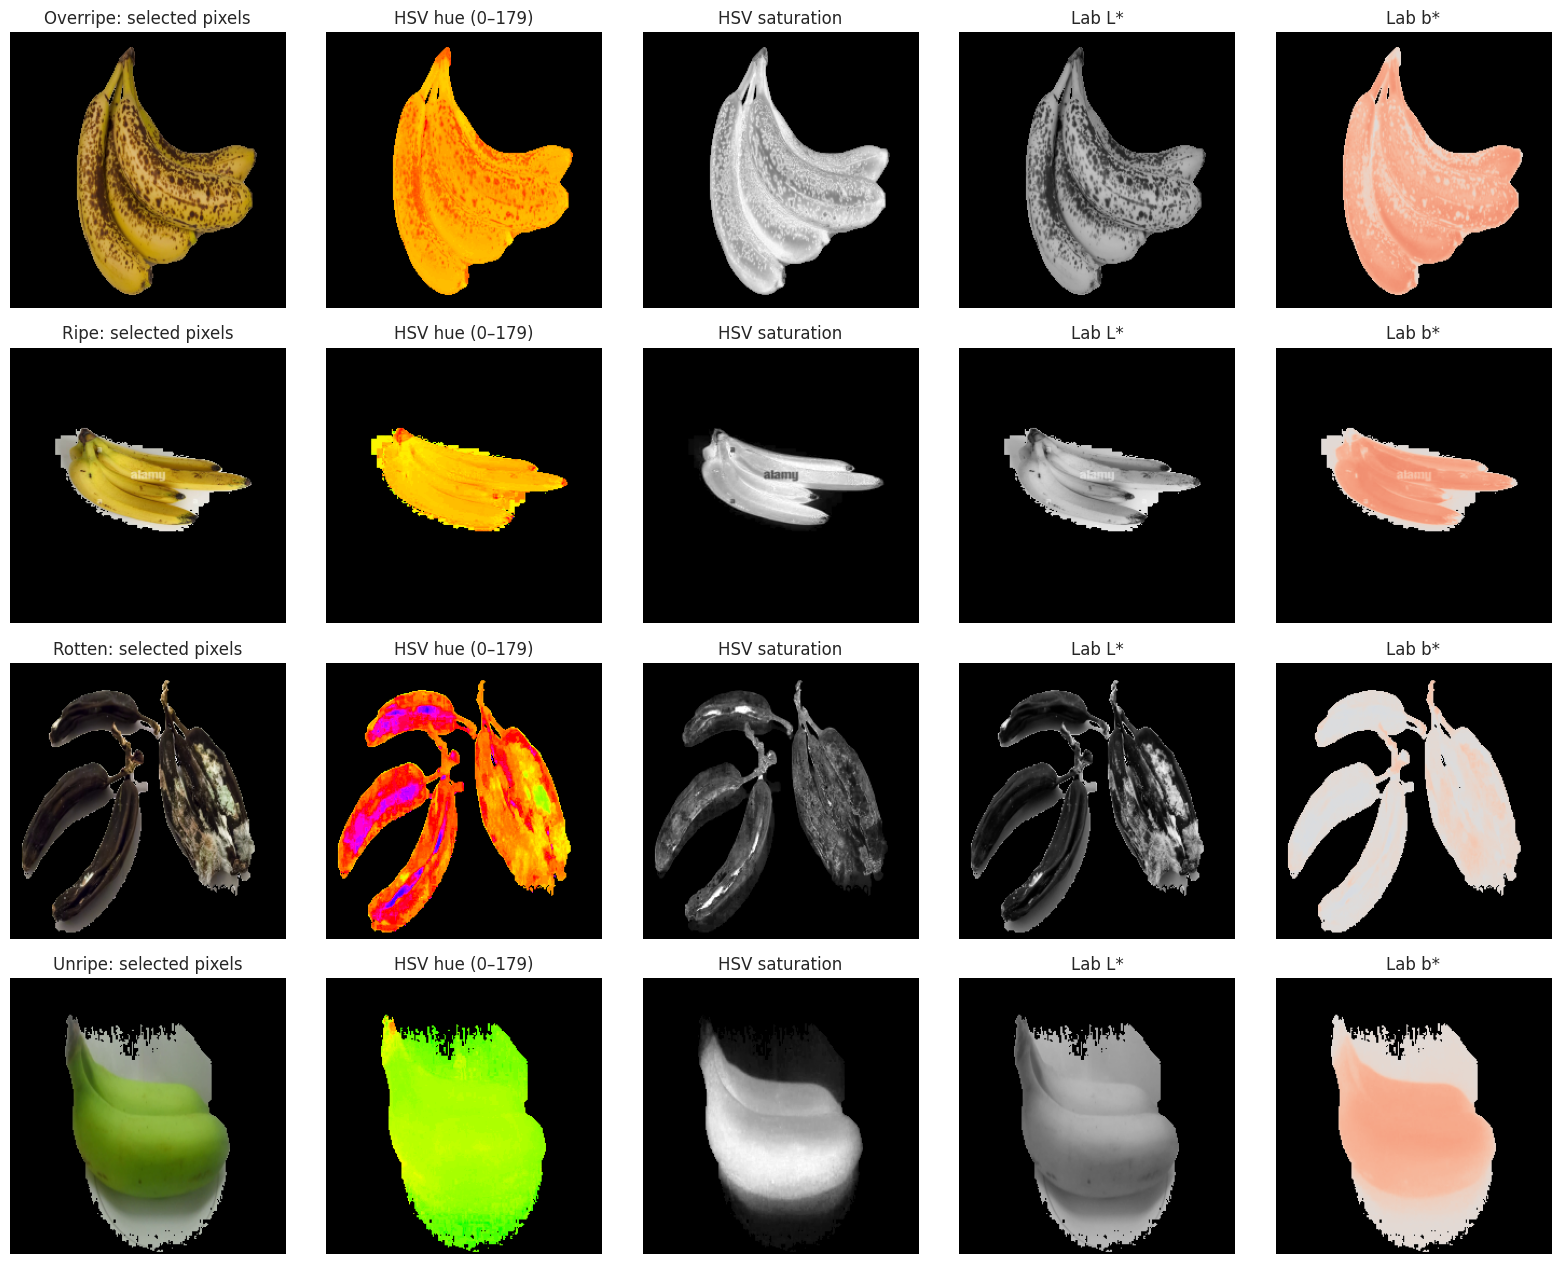

,mask_area_fraction,informative_pixel_fraction,adaptive_saturation_floor,adaptive_chroma_floor,hsv_s_mean,hsv_v_mean,lab_l_mean,lab_a_mean,lab_b_mean,green_fraction,yellow_fraction,brown_orange_fraction,dark_fraction,adaptive_spot_fraction
label,,,,,,,,,,,,,,
Overripe,0.307,0.998,0.250,18.000,0.761,0.605,50.926,7.531,45.526,0.000,0.768,0.231,0.144,0.031
Ripe,0.210,0.705,0.040,3.000,0.628,0.728,66.915,-0.214,46.560,0.000,0.813,0.024,0.026,0.055
Rotten,0.348,0.978,0.106,3.000,0.287,0.282,26.427,2.334,5.983,0.007,0.217,0.498,0.671,0.297
Unripe,0.394,0.924,0.059,5.657,0.504,0.544,54.662,-18.382,30.826,0.697,0.045,0.000,0.007,0.000


In [ ]:
# HSV separates:
# - Hue: green, yellow or brown colour
# - Saturation: colour strength
# - Value: brightness
# CIE L*a*b* separates:
# - L*: lightness
# - a*: green-to-red change
# - b*: blue-to-yellow change
# - C*: colour strength
diagnostic_feature_rows = []
diagnostic_samples = list(sample_rows.itertuples(index=False))
fig, axes = plt.subplots(
    len(diagnostic_samples), 5,
    figsize=(16, 3.2 * len(diagnostic_samples)),
)
if len(diagnostic_samples) == 1:
    axes = np.expand_dims(axes, axis=0)

hue_cmap = plt.get_cmap("hsv").copy()
hue_cmap.set_bad("black")
gray_cmap = plt.get_cmap("gray").copy()
gray_cmap.set_bad("black")
lab_cmap = plt.get_cmap("coolwarm").copy()
lab_cmap.set_bad("black")

for row_axes, row in zip(axes, diagnostic_samples):
    try:
        resized, mask, _ = preprocess_image(row.path)
        maps = adaptive_hsv_lab_maps(resized, mask)
        feature_values = extract_adaptive_hsv_lab_features(resized, mask)
        informative = maps["informative"]

        selected_rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB).copy()
        selected_rgb[~informative] = 0
        hue_map = np.ma.masked_where(~informative, maps["hue"])
        saturation_map = np.ma.masked_where(~informative, maps["saturation"])
        lightness_map = np.ma.masked_where(~informative, maps["lightness"])
        b_star_map = np.ma.masked_where(~informative, maps["b_star"])

        panels = [
            (selected_rgb, None, None, None, f"{row.label}: selected pixels"),
            (hue_map, hue_cmap, 0, 179, "HSV hue (0–179)"),
            (saturation_map, gray_cmap, 0, 1, "HSV saturation"),
            (lightness_map, gray_cmap, 0, 100, "Lab L*"),
            (b_star_map, lab_cmap, -128, 127, "Lab b*"),
        ]
        for ax, (panel, cmap, vmin, vmax, title) in zip(row_axes, panels):
            ax.imshow(panel, cmap=cmap, vmin=vmin, vmax=vmax)
            ax.set_title(title)
            ax.axis("off")

        diagnostic_feature_rows.append({"label": row.label, **feature_values})
    except Exception as exc:
        warnings.warn(f"Could not produce Part B preview for {row.path}: {exc}")
        for ax in row_axes:
            ax.axis("off")
            ax.text(0.5, 0.5, f"{row.label}\npreview unavailable", ha="center", va="center")

plt.tight_layout()
plt.show()

preview_columns = [
    "mask_area_fraction",
    "informative_pixel_fraction",
    "adaptive_saturation_floor",
    "adaptive_chroma_floor",
    "hsv_s_mean",
    "hsv_v_mean",
    "lab_l_mean",
    "lab_a_mean",
    "lab_b_mean",
    "green_fraction",
    "yellow_fraction",
    "brown_orange_fraction",
    "dark_fraction",
    "adaptive_spot_fraction",
]

if diagnostic_feature_rows:
    diagnostic_table = pd.DataFrame(diagnostic_feature_rows).set_index("label")
    display(diagnostic_table[preview_columns].round(3))



## 4. Part C — extract and store features

GrabCut is the slowest step. On Colab, processing the full dataset can take a
few minutes. Failed/corrupt images are logged rather than stopping the run.



In [ ]:
records = []
failures = []

for row in tqdm(image_index.itertuples(index=False), total=len(image_index), desc="Extracting features"):
    try:
        resized, mask, _ = preprocess_image(row.path)
        feature_values = extract_adaptive_hsv_lab_features(resized, mask)
        records.append({
            "path": row.path,
            "label": row.label,
            "split": row.split,
            **feature_values,
        })
    except Exception as exc:
        failures.append({"path": row.path, "reason": str(exc)})

features_df = pd.DataFrame(records)
if features_df.empty:
    raise RuntimeError("Feature extraction failed for every image.")

feature_columns = [column for column in features_df.columns if column not in {"path", "label", "split"}]
features_df[feature_columns] = features_df[feature_columns].replace([np.inf, -np.inf], np.nan)

bad_feature_rows = features_df[feature_columns].isna().any(axis=1)
if bad_feature_rows.any():
    warnings.warn(f"Dropping {bad_feature_rows.sum()} row(s) containing invalid feature values.")
    features_df = features_df.loc[~bad_feature_rows].reset_index(drop=True)

FEATURES_CSV = OUTPUT_DIR / "banana_hsv_lab_features.csv"
FAILURES_CSV = OUTPUT_DIR / "failed_images.csv"
features_df.to_csv(FEATURES_CSV, index=False)
pd.DataFrame(failures, columns=["path", "reason"]).to_csv(FAILURES_CSV, index=False)

print(f"Saved {len(features_df):,} feature rows with {len(feature_columns)} features to {FEATURES_CSV}")
print(f"Failed images: {len(failures)} (log: {FAILURES_CSV})")
display(features_df.head())



Extracting features:   0%|          | 0/1200 [00:00<?, ?it/s]

Saved 1,200 feature rows with 121 features to /content/banana_svm_outputs/banana_hsv_lab_features.csv
Failed images: 0 (log: /content/banana_svm_outputs/failed_images.csv)


,path,label,split,mask_area_fraction,adaptive_saturation_floor,adaptive_chroma_floor,informative_pixel_fraction,hsv_s_mean,hsv_s_std,hsv_s_p10,...,lab_b_hist_08,lab_b_hist_09,green_fraction,yellow_fraction,brown_orange_fraction,dark_fraction,adaptive_dark_limit,adaptive_spot_fraction,lab_l_laplacian_abs_mean,lab_l_laplacian_std
0,/kaggle/input/banalyzer-banana-ripeness-classi...,Unripe,train,0.389801,0.250000,13.152946,0.996320,0.665843,0.152165,0.533333,...,0.000000,0.0,0.006679,0.947627,0.024399,0.118223,40.000000,0.131935,22.344555,49.958447
1,/kaggle/input/banalyzer-banana-ripeness-classi...,Unripe,train,0.238083,0.250000,18.000000,1.000000,0.782688,0.194821,0.521569,...,0.000000,0.0,0.272960,0.724732,0.002307,0.011985,35.882353,0.019676,24.486830,46.043682
2,/kaggle/input/banalyzer-banana-ripeness-classi...,Unripe,train,0.115540,0.250000,18.000000,1.000000,0.654360,0.214705,0.337255,...,0.000000,0.0,0.389065,0.610935,0.000000,0.014527,40.000000,0.068542,14.171685,27.577974
3,/kaggle/input/banalyzer-banana-ripeness-classi...,Unripe,train,0.098633,0.156863,18.000000,0.939666,0.422770,0.208983,0.192157,...,0.000000,0.0,0.928383,0.034409,0.000494,0.020909,40.000000,0.033092,68.131500,118.561012
4,/kaggle/input/banalyzer-banana-ripeness-classi...,Unripe,train,0.128098,0.184314,11.180340,0.943657,0.628639,0.256844,0.262745,...,0.000757,0.0,0.270639,0.655895,0.029664,0.122065,26.078430,0.098712,103.032280,185.272507


## 5. Train and evaluate the SVM

`StandardScaler` is fitted only on training folds. `GridSearchCV` selects the
RBF-SVM hyperparameters using stratified cross-validation and balanced accuracy.
The held-out test data is evaluated once at the end.



In [ ]:
available_splits = set(features_df["split"].str.lower())
has_official_test = "test" in available_splits
has_non_test_data = any(split != "test" for split in available_splits)

if has_official_test and has_non_test_data:
    train_frame = features_df[features_df["split"].str.lower() != "test"].copy()
    test_frame = features_df[features_df["split"].str.lower() == "test"].copy()
    split_description = "dataset-provided test split"
else:
    train_frame, test_frame = train_test_split(
        features_df,
        test_size=0.20,
        random_state=RANDOM_SEED,
        stratify=features_df["label"],
    )
    split_description = "reproducible stratified 80/20 split"

X_train = train_frame[feature_columns]
y_train = train_frame["label"]
X_test = test_frame[feature_columns]
y_test = test_frame["label"]

print("Evaluation split:", split_description)
print("Training images:", len(train_frame), "| Test images:", len(test_frame))
display(pd.DataFrame({
    "train": y_train.value_counts(),
    "test": y_test.value_counts(),
}).fillna(0).astype(int))

minimum_class_count = int(y_train.value_counts().min())
cv_folds = min(5, minimum_class_count)
if cv_folds < 2:
    raise RuntimeError("At least two training images per class are required for cross-validation.")

pipeline = Pipeline([
    ("scale", StandardScaler()),
    ("svm", SVC(kernel="rbf", class_weight="balanced")),
])

parameter_grid = {
    "svm__C": [1, 10, 100],
    "svm__gamma": ["scale", 0.01, 0.1],
}

search = GridSearchCV(
    estimator=pipeline,
    param_grid=parameter_grid,
    scoring="balanced_accuracy",
    cv=StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_SEED),
    n_jobs=-1,
    refit=True,
    verbose=1,
)
search.fit(X_train, y_train)

predictions = search.predict(X_test)
accuracy = accuracy_score(y_test, predictions)
balanced_accuracy = balanced_accuracy_score(y_test, predictions)
macro_f1 = f1_score(y_test, predictions, average="macro")

print("Best SVM parameters:", search.best_params_)
print(f"Best CV balanced accuracy: {search.best_score_:.4f}")
print(f"Test accuracy:          {accuracy:.4f} ({accuracy * 100:.2f}%)")
print(f"Test balanced accuracy: {balanced_accuracy:.4f}")
print(f"Test macro F1:          {macro_f1:.4f}")
print("\nClassification report:\n")
print(classification_report(y_test, predictions, digits=4, zero_division=0))



Evaluation split: dataset-provided test split
Training images: 1000 | Test images: 200


,train,test
label,,
Unripe,250,50
Overripe,250,50
Rotten,250,50
Ripe,250,50


Fitting 5 folds for each of 9 candidates, totalling 45 fits
Best SVM parameters: {'svm__C': 100, 'svm__gamma': 0.01}
Best CV balanced accuracy: 0.9250
Test accuracy:          0.9150 (91.50%)
Test balanced accuracy: 0.9150
Test macro F1:          0.9139

Classification report:

              precision    recall  f1-score   support

    Overripe     0.8913    0.8200    0.8542        50
        Ripe     0.9000    0.9000    0.9000        50
      Rotten     0.9400    0.9400    0.9400        50
      Unripe     0.9259    1.0000    0.9615        50

    accuracy                         0.9150       200
   macro avg     0.9143    0.9150    0.9139       200
weighted avg     0.9143    0.9150    0.9139       200



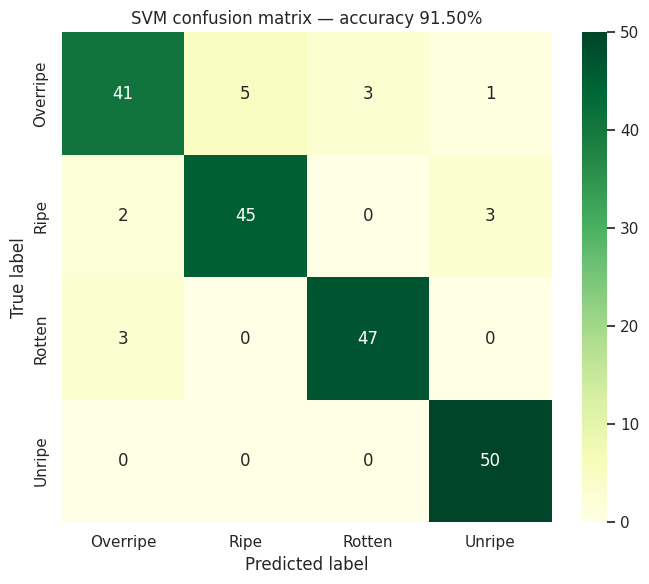

In [ ]:
class_names = list(search.best_estimator_.named_steps["svm"].classes_)
matrix = confusion_matrix(y_test, predictions, labels=class_names)

plt.figure(figsize=(7, 6))
sns.heatmap(
    matrix,
    annot=True,
    fmt="d",
    cmap="YlGn",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title(f"SVM confusion matrix — accuracy {accuracy:.2%}")
plt.tight_layout()
plt.show()



## 6. Save the trained model and evaluation outputs



In [ ]:
MODEL_FILE = OUTPUT_DIR / "banana_ripeness_svm.joblib"
REPORT_FILE = OUTPUT_DIR / "classification_report.csv"

model_bundle = {
    "model": search.best_estimator_,
    "feature_columns": feature_columns,
    "image_size": IMAGE_SIZE,
    "grabcut_iterations": GRABCUT_ITERATIONS,
    "segmentation": "HSV/Lab-seeded GrabCut with dark-background recovery and morphology",
    "classes": class_names,
}
joblib.dump(model_bundle, MODEL_FILE)

report_df = pd.DataFrame(
    classification_report(y_test, predictions, output_dict=True, zero_division=0)
).transpose()
report_df.to_csv(REPORT_FILE)

print("Saved model:", MODEL_FILE)
print("Saved report:", REPORT_FILE)



Saved model: /content/banana_svm_outputs/banana_ripeness_svm.joblib
Saved report: /content/banana_svm_outputs/classification_report.csv


## 7. Optional: classify one new image



In [ ]:
def predict_one_image(image_path, saved_bundle=model_bundle):
    resized, mask, _ = preprocess_image(image_path)
    values = extract_adaptive_hsv_lab_features(resized, mask)
    row = pd.DataFrame([values])[saved_bundle["feature_columns"]]
    predicted_label = saved_bundle["model"].predict(row)[0]
    return predicted_label, mask


# Example:
# label, mask = predict_one_image(image_index.iloc[0]["path"])
# print("Prediction:", label)


In [ ]:
failed_df = pd.read_csv(
    "/content/banana_svm_outputs/failed_images.csv"
)

# Add each image's class and dataset split
failed_details = failed_df.merge(
    image_index,
    on="path",
    how="left"
)

display(failed_details[["path", "label", "split", "reason"]])

,path,label,split,reason


In [ ]:
if failed_df.empty:
    print("No failed images.")
else:
    fig, axes = plt.subplots(
        len(failed_df),
        1,
        figsize=(8, 5 * len(failed_df))
    )

    axes = np.atleast_1d(axes)

    for ax, row in zip(axes, failed_df.itertuples(index=False)):
        try:
            image = load_validate_resize(row.path)
            image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

            details = image_index[image_index["path"] == row.path]
            if not details.empty:
                label = details.iloc[0]["label"]
                split = details.iloc[0]["split"]
            else:
                label = "Unknown"
                split = "Unknown"

            ax.imshow(image_rgb)
            ax.set_title(
                f"Label: {label} | Split: {split}\n"
                f"Failure: {row.reason}"
            )
        except Exception as exc:
            ax.text(
                0.5,
                0.5,
                f"Image cannot be opened\n{exc}",
                ha="center",
                va="center"
            )

        ax.axis("off")

    plt.tight_layout()
    plt.show()

No failed images.


In [ ]:
for row in failed_df.itertuples(index=False):
    image = load_validate_resize(row.path)

    try:
        mask = generate_fruit_mask(image)
        foreground = cv2.bitwise_and(image, image, mask=mask)
    except Exception as exc:
        mask = np.zeros(image.shape[:2], dtype=np.uint8)
        foreground = np.zeros_like(image)
        print(f"{Path(row.path).name}: {exc}")

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))

    axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    axes[0].set_title("Original")

    axes[1].imshow(mask, cmap="gray")
    axes[1].set_title("Generated mask")

    axes[2].imshow(cv2.cvtColor(foreground, cv2.COLOR_BGR2RGB))
    axes[2].set_title("Foreground")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

# Eugene Image Processing
## Marker-Controlled Watershed

**Pipeline flow:**  
`Shared Pre-processing → Marker-Controlled Watershed → Colour Cut-Out → Shared RBF-SVM Training Procedure → Evaluation → Comparison with Shared Original RGB Baseline`

This section reuses the shared imports, shared dataset, shared Original RGB baseline, and shared pre-processing functions defined above. No dataset is downloaded again and no second GrabCut refinement is applied here.

**Additional imports:** None. All required libraries (`cv2`, `numpy`, `pandas`, `matplotlib`, and scikit-learn utilities) are already available from the shared import section.


### Part E1 — Marker-Controlled Watershed

The shared function `preprocess_image(path)` is used first. It already returns:

- `resized_bgr`: validated and resized image,
- `shared_mask`: shared fruit mask,
- `shared_foreground_bgr`: fruit foreground produced by the shared pre-processing.

The shared fruit mask is then used to generate reliable foreground and background markers for Marker-Controlled Watershed. A Euclidean distance transform is used to obtain sure-foreground regions inside the existing fruit mask. The unknown boundary region is left unlabeled so Watershed can determine the final boundary from the image.


In [ ]:
# E1 — MARKER-CONTROLLED WATERSHED PARAMETERS
# Only parameters specific to Watershed are defined here.
# Shared IMAGE_SIZE, dataset variables, preprocessing functions and SVM helpers
# are reused directly and are NOT redefined.

WATERSHED_FOREGROUND_DISTANCE_RATIO = 0.35
WATERSHED_MARKER_KERNEL_SIZE = 3
WATERSHED_ENVELOPE_DILATION_ITERATIONS = 3

print("Watershed foreground distance ratio:", WATERSHED_FOREGROUND_DISTANCE_RATIO)
print("Watershed marker kernel size       :", WATERSHED_MARKER_KERNEL_SIZE)
print("Watershed envelope dilation        :", WATERSHED_ENVELOPE_DILATION_ITERATIONS)


Watershed foreground distance ratio: 0.35
Watershed marker kernel size       : 3
Watershed envelope dilation        : 3


In [ ]:
# E2 — APPLY MARKER-CONTROLLED WATERSHED AFTER SHARED PRE-PROCESSING

def apply_marker_controlled_watershed(path):
    # 1. Reuse the shared pre-processing exactly as defined above.
    resized_bgr, shared_mask, shared_foreground_bgr = (
        shared_preprocess_image(path)
    )

    binary_mask = (shared_mask > 0).astype(np.uint8)
    if np.count_nonzero(binary_mask) == 0:
        raise ValueError(f"Shared preprocessing produced an empty fruit mask: {path}")

    # 2. Euclidean distance transform.
    distance = cv2.distanceTransform(binary_mask, cv2.DIST_L2, 5)
    max_distance = float(distance.max())
    if max_distance <= 0:
        raise ValueError(f"Distance transform is empty: {path}")

    # 3. Sure-foreground markers from the interior of the shared fruit mask.
    sure_foreground = np.where(
        distance >= WATERSHED_FOREGROUND_DISTANCE_RATIO * max_distance,
        255,
        0,
    ).astype(np.uint8)

    # 4. Create an envelope around the shared mask.
    #    Pixels between the sure foreground and this envelope are left unknown.
    marker_kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (WATERSHED_MARKER_KERNEL_SIZE, WATERSHED_MARKER_KERNEL_SIZE),
    )
    foreground_envelope = cv2.dilate(
        binary_mask,
        marker_kernel,
        iterations=WATERSHED_ENVELOPE_DILATION_ITERATIONS,
    )
    unknown = cv2.subtract(
        (foreground_envelope * 255).astype(np.uint8),
        sure_foreground,
    )

    # 5. Label the sure-foreground components.
    _, markers = cv2.connectedComponents(
        (sure_foreground > 0).astype(np.uint8),
        connectivity=8,
    )
    markers = markers.astype(np.int32) + 1

    # Background remains label 1; unknown boundary pixels become label 0.
    markers[unknown > 0] = 0

    # 6. Marker-Controlled Watershed.
    watershed_labels = markers.copy()
    cv2.watershed(resized_bgr.copy(), watershed_labels)

    # 7. Keep Watershed foreground regions and restrict them to the shared mask.
    watershed_mask = np.where(
        (watershed_labels > 1) & (shared_mask > 0),
        255,
        0,
    ).astype(np.uint8)

    # Safety fallback: never return an empty cut-out if a valid shared mask exists.
    if np.count_nonzero(watershed_mask) < 64:
        watershed_mask = shared_mask.copy()

    colour_cutout_bgr = cv2.bitwise_and(
        shared_foreground_bgr,
        shared_foreground_bgr,
        mask=watershed_mask,
    )
    colour_cutout_rgb = cv2.cvtColor(colour_cutout_bgr, cv2.COLOR_BGR2RGB)

    return {
        "resized_bgr": resized_bgr,
        "shared_mask": shared_mask,
        "shared_foreground_bgr": shared_foreground_bgr,
        "distance_transform": distance,
        "sure_foreground": sure_foreground,
        "foreground_envelope": foreground_envelope,
        "unknown": unknown,
        "markers": markers,
        "watershed_labels": watershed_labels,
        "watershed_mask": watershed_mask,
        "colour_cutout_rgb": colour_cutout_rgb,
    }


### Part E2 — Visual Check of the Watershed Stages

The following cell uses one image from each class in the shared official test set. It does not create a new dataset or perform additional pre-processing.


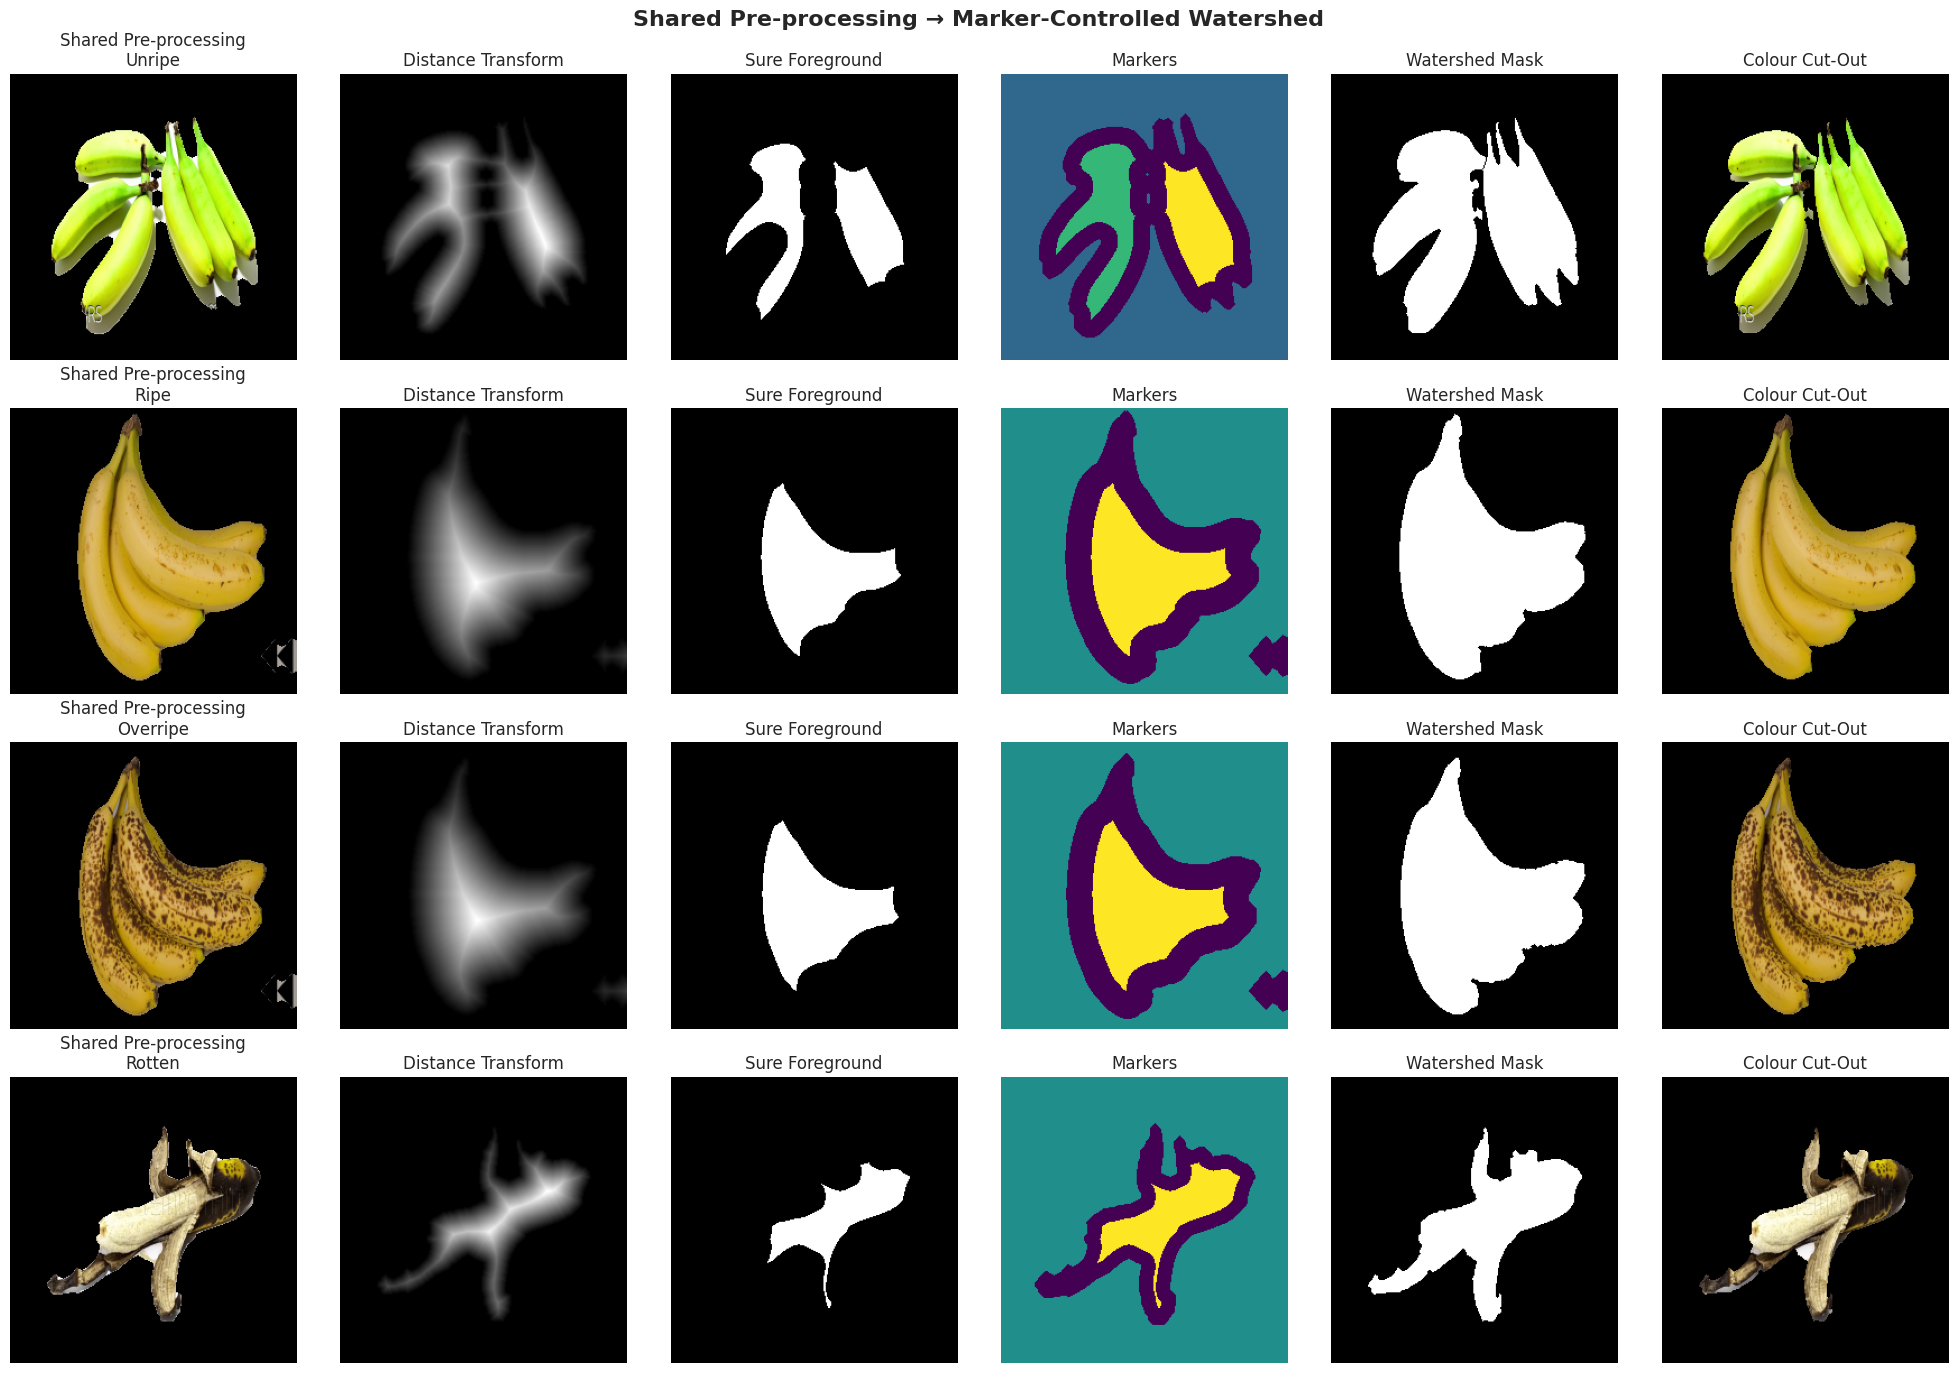

In [ ]:
# E3 — VISUALISE SHARED PRE-PROCESSING → WATERSHED

examples = (
    test_df.groupby("label", sort=False)
    .head(1)
    .set_index("label")
    .reindex(LABELS)
    .dropna()
    .reset_index()
)

fig, axes = plt.subplots(len(examples), 6, figsize=(20, 3.5 * len(examples)))
if len(examples) == 1:
    axes = np.expand_dims(axes, axis=0)

for row, sample in examples.iterrows():
    result = apply_marker_controlled_watershed(sample["path"])

    shared_foreground_rgb = cv2.cvtColor(
        result["shared_foreground_bgr"], cv2.COLOR_BGR2RGB
    )

    marker_view = cv2.normalize(
        result["markers"].astype(np.float32),
        None,
        0,
        255,
        cv2.NORM_MINMAX,
    ).astype(np.uint8)

    panels = [
        (shared_foreground_rgb, f"Shared Pre-processing\n{sample['label']}", None),
        (result["distance_transform"], "Distance Transform", "gray"),
        (result["sure_foreground"], "Sure Foreground", "gray"),
        (marker_view, "Markers", "viridis"),
        (result["watershed_mask"], "Watershed Mask", "gray"),
        (result["colour_cutout_rgb"], "Colour Cut-Out", None),
    ]

    for col, (image, title, cmap) in enumerate(panels):
        axes[row, col].imshow(image, cmap=cmap)
        axes[row, col].set_title(title)
        axes[row, col].axis("off")

plt.suptitle(
    "Shared Pre-processing → Marker-Controlled Watershed",
    fontsize=16,
    fontweight="bold",
)
plt.tight_layout()
plt.show()


### Part E3 — Train the SVM Using Watershed Colour Cut-Outs

Only the feature source changes. The shared `rgb_pixel_vector`, `build_matrix`, `make_search`, SVM parameter grid, training/test split, and evaluation labels are reused so that the Watershed result can be compared fairly with the shared Original RGB baseline.


In [ ]:
# E4 — BUILD WATERSHED COLOUR FEATURES AND TRAIN SVM

def watershed_feature(path):
    result = apply_marker_controlled_watershed(path)
    return rgb_pixel_vector(result["colour_cutout_rgb"])


X_train_watershed = build_matrix(
    train_df,
    watershed_feature,
    "Watershed train",
)
X_test_watershed = build_matrix(
    test_df,
    watershed_feature,
    "Watershed test",
)

# Reuse the shared SVM search procedure and the same parameter grid.
watershed_search = make_search()
watershed_search.fit(X_train_watershed, y_train)

WATERSHED_C = watershed_search.best_params_["svm__C"]
WATERSHED_GAMMA = watershed_search.best_params_["svm__gamma"]

watershed_model = make_final_svm(WATERSHED_C, WATERSHED_GAMMA)
watershed_model.fit(X_train_watershed, y_train)

print("Marker-Controlled Watershed SVM trained")
print("Best C:", WATERSHED_C)
print("Best gamma:", WATERSHED_GAMMA)
print(f"Training CV accuracy: {watershed_search.best_score_ * 100:.2f}%")


Watershed train: 100/1000
Watershed train: 200/1000
Watershed train: 300/1000
Watershed train: 400/1000
Watershed train: 500/1000
Watershed train: 600/1000
Watershed train: 700/1000
Watershed train: 800/1000
Watershed train: 900/1000
Watershed train: 1000/1000
Watershed test: 100/200
Watershed test: 200/200
Marker-Controlled Watershed SVM trained
Best C: 100
Best gamma: scale
Training CV accuracy: 82.40%


### Part E4 — Watershed Classification Result


Watershed Test Accuracy : 79.50%
Watershed Macro F1      : 79.47%

Classification Report:

              precision    recall  f1-score   support

      Unripe       0.78      0.70      0.74        50
        Ripe       0.70      0.78      0.74        50
    Overripe       0.83      0.78      0.80        50
      Rotten       0.88      0.92      0.90        50

    accuracy                           0.80       200
   macro avg       0.80      0.79      0.79       200
weighted avg       0.80      0.80      0.79       200



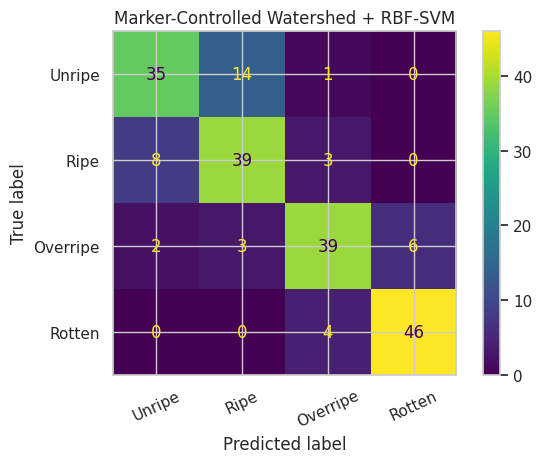

In [ ]:
# E5 — WATERSHED TEST RESULT

watershed_pred = watershed_model.predict(X_test_watershed)
watershed_accuracy = accuracy_score(y_test, watershed_pred)
watershed_macro_f1 = f1_score(y_test, watershed_pred, average="macro")

print(f"Watershed Test Accuracy : {watershed_accuracy * 100:.2f}%")
print(f"Watershed Macro F1      : {watershed_macro_f1 * 100:.2f}%")
print("\nClassification Report:\n")
print(
    classification_report(
        y_test,
        watershed_pred,
        labels=LABELS,
        zero_division=0,
    )
)

watershed_cm = confusion_matrix(
    y_test,
    watershed_pred,
    labels=LABELS,
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=watershed_cm,
    display_labels=LABELS,
)
disp.plot(values_format="d", colorbar=True)
plt.title("Marker-Controlled Watershed + RBF-SVM")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


### Part E5 — Compare with the Shared Original RGB Baseline

The comparison reuses the already calculated shared baseline results. No baseline model is retrained inside Eugene's section.


In [ ]:
# E6 — ORIGINAL RGB BASELINE vs MARKER-CONTROLLED WATERSHED

comparison_watershed = pd.DataFrame([
    {
        "Method": "Original RGB Baseline",
        "Test Accuracy (%)": baseline_accuracy * 100,
        "Macro F1 (%)": baseline_macro_f1 * 100,
        "Correct / Total": (
            f"{int(np.sum(baseline_pred == y_test))}/{len(y_test)}"
        ),
    },
    {
        "Method": "Marker-Controlled Watershed",
        "Test Accuracy (%)": watershed_accuracy * 100,
        "Macro F1 (%)": watershed_macro_f1 * 100,
        "Correct / Total": (
            f"{int(np.sum(watershed_pred == y_test))}/{len(y_test)}"
        ),
    },
])

display(comparison_watershed.round(2))

accuracy_change = (watershed_accuracy - baseline_accuracy) * 100
f1_change = (watershed_macro_f1 - baseline_macro_f1) * 100

print(
    f"Accuracy change vs Original RGB baseline: "
    f"{accuracy_change:+.2f} percentage points"
)
print(
    f"Macro F1 change vs Original RGB baseline: "
    f"{f1_change:+.2f} percentage points"
)


,Method,Test Accuracy (%),Macro F1 (%),Correct / Total
0,Original RGB Baseline,83.5,83.44,167/200
1,Marker-Controlled Watershed,79.5,79.47,159/200


Accuracy change vs Original RGB baseline: -4.00 percentage points
Macro F1 change vs Original RGB baseline: -3.97 percentage points


## Part E6 — Hybrid Watershed + Adaptive Colour Constancy

In [ ]:
# ============================================================
# PART E6 — WATERSHED + MORPHOLOGICAL BOUNDARY RECOVERY
# ============================================================

RECOVERY_KERNEL_SIZE = 5
RECOVERY_CLOSE_ITERATIONS = 2
RECOVERY_DILATE_ITERATIONS = 1

print("Recovery kernel:", RECOVERY_KERNEL_SIZE)
print("Closing iterations:", RECOVERY_CLOSE_ITERATIONS)
print("Dilation iterations:", RECOVERY_DILATE_ITERATIONS)

Recovery kernel: 5
Closing iterations: 2
Dilation iterations: 1


In [ ]:
# ============================================================
# PART E6.1 — MORPHOLOGICAL MASK REFINEMENT
# ============================================================

def apply_watershed_boundary_recovery(path):

    # --------------------------------------------------------
    # 1. Run Marker-Controlled Watershed
    #    This already uses SHARED preprocessing
    # --------------------------------------------------------
    watershed_result = apply_marker_controlled_watershed(
        path
    )

    # Reuse outputs from the SAME shared preprocessing
    watershed_mask = watershed_result[
        "watershed_mask"
    ]

    shared_mask = watershed_result[
        "shared_mask"
    ]

    shared_foreground_bgr = watershed_result[
        "shared_foreground_bgr"
    ]

    # --------------------------------------------------------
    # 2. Morphological kernel
    # --------------------------------------------------------
    recovery_kernel = cv2.getStructuringElement(
        cv2.MORPH_ELLIPSE,
        (
            RECOVERY_KERNEL_SIZE,
            RECOVERY_KERNEL_SIZE
        )
    )

    # --------------------------------------------------------
    # 3. Morphological closing
    #    Fill small gaps and reconnect banana boundaries
    # --------------------------------------------------------
    recovered_mask = cv2.morphologyEx(
        watershed_mask,
        cv2.MORPH_CLOSE,
        recovery_kernel,
        iterations=RECOVERY_CLOSE_ITERATIONS
    )

    # --------------------------------------------------------
    # 4. Controlled dilation
    #    Recover boundary pixels removed by Watershed
    # --------------------------------------------------------
    recovered_mask = cv2.dilate(
        recovered_mask,
        recovery_kernel,
        iterations=RECOVERY_DILATE_ITERATIONS
    )

    # --------------------------------------------------------
    # 5. Restrict recovery to SHARED fruit mask
    #    Prevent background from being added
    # --------------------------------------------------------
    recovered_mask = cv2.bitwise_and(
        recovered_mask,
        shared_mask
    )

    # Safety fallback
    if np.count_nonzero(recovered_mask) < 64:
        recovered_mask = watershed_mask.copy()

    # --------------------------------------------------------
    # 6. Generate recovered colour cut-out
    # --------------------------------------------------------
    recovered_cutout_bgr = cv2.bitwise_and(
        shared_foreground_bgr,
        shared_foreground_bgr,
        mask=recovered_mask
    )

    recovered_cutout_rgb = cv2.cvtColor(
        recovered_cutout_bgr,
        cv2.COLOR_BGR2RGB
    )

    # --------------------------------------------------------
    # 7. Retention information
    # --------------------------------------------------------
    shared_area = np.count_nonzero(
        shared_mask
    )

    watershed_area = np.count_nonzero(
        watershed_mask
    )

    recovered_area = np.count_nonzero(
        recovered_mask
    )

    watershed_retention = (
        watershed_area / shared_area
        if shared_area > 0
        else 0
    )

    recovered_retention = (
        recovered_area / shared_area
        if shared_area > 0
        else 0
    )

    return {
        "watershed_mask":
            watershed_mask,

        "recovered_mask":
            recovered_mask,

        "watershed_cutout_rgb":
            watershed_result[
                "colour_cutout_rgb"
            ],

        "recovered_cutout_rgb":
            recovered_cutout_rgb,

        "watershed_retention":
            watershed_retention,

        "recovered_retention":
            recovered_retention
    }

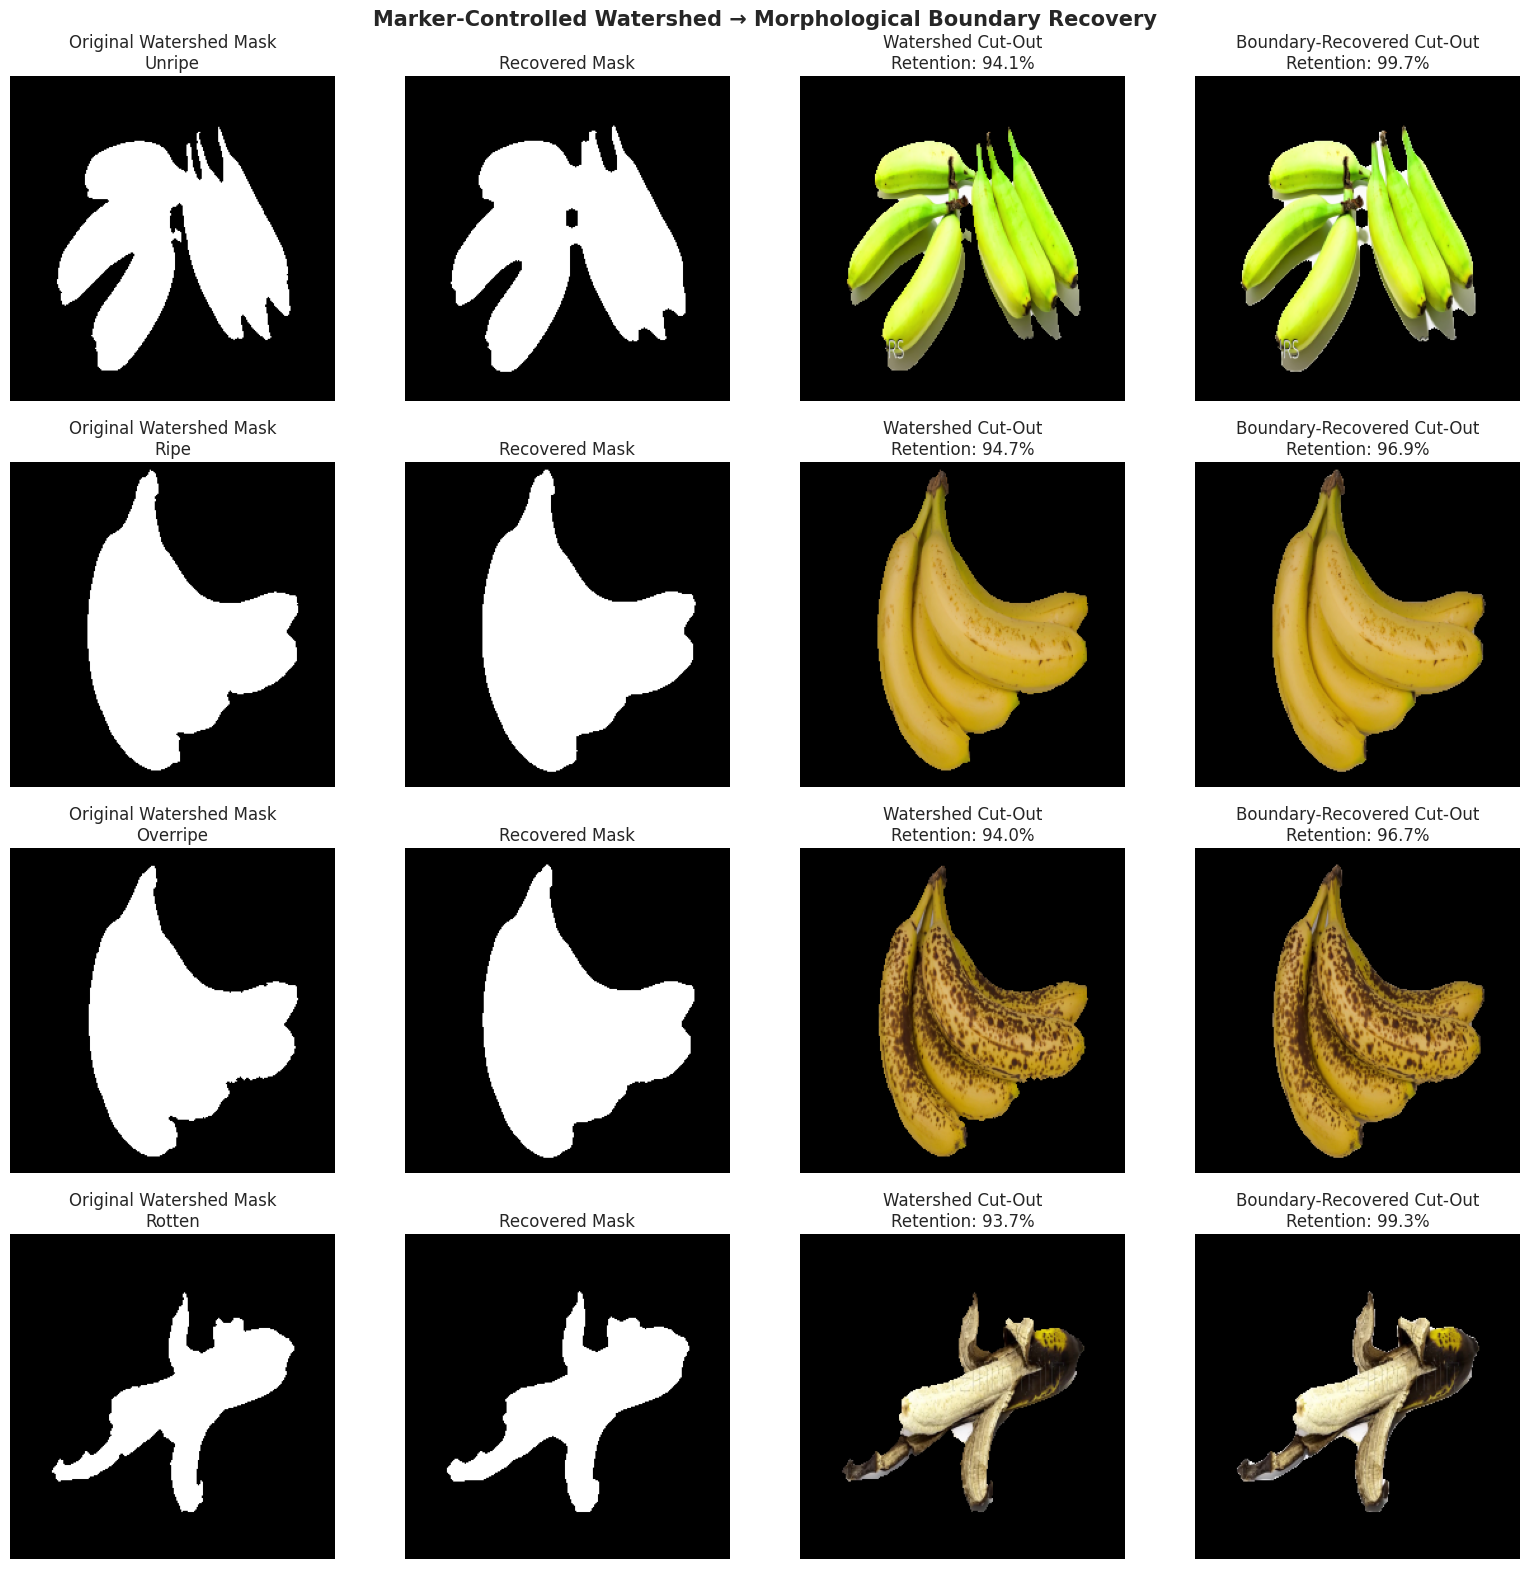

In [ ]:
# ============================================================
# PART E6.2 — VISUAL CHECK
# ============================================================

# Re-initializing LABELS and test_df for this section to ensure definitions
# are available, similar to the scope setup in 'Part F1: Contrast Enhancement and Texture Analysis'.
LABELS = ["Unripe", "Ripe", "Overripe", "Rotten"]
test_df = image_index[image_index["split"] == "test"].copy()

examples = (
    test_df
    .groupby("label", sort=False)
    .head(1)
    .set_index("label")
    .reindex(LABELS)
    .dropna()
    .reset_index()
)

fig, axes = plt.subplots(
    len(examples),
    4,
    figsize=(16, 4 * len(examples))
)

if len(examples) == 1:
    axes = np.expand_dims(
        axes,
        axis=0
    )

for row, sample in examples.iterrows():

    result = apply_watershed_boundary_recovery(
        sample["path"]
    )

    # Original Watershed Mask
    axes[row, 0].imshow(
        result["watershed_mask"],
        cmap="gray"
    )

    axes[row, 0].set_title(
        f"Original Watershed Mask\n"
        f"{sample['label']}"
    )

    # Recovered Mask
    axes[row, 1].imshow(
        result["recovered_mask"],
        cmap="gray"
    )

    axes[row, 1].set_title(
        "Recovered Mask"
    )

    # Watershed Colour Cut-Out
    axes[row, 2].imshow(
        result["watershed_cutout_rgb"]
    )

    axes[row, 2].set_title(
        f"Watershed Cut-Out\n"
        f"Retention: "
        f"{result['watershed_retention'] * 100:.1f}%"
    )

    # Boundary-Recovered Cut-Out
    axes[row, 3].imshow(
        result["recovered_cutout_rgb"]
    )

    axes[row, 3].set_title(
        f"Boundary-Recovered Cut-Out\n"
        f"Retention: "
        f"{result['recovered_retention'] * 100:.1f}%"
    )

    for col in range(4):
        axes[row, col].axis(
            "off"
        )

plt.suptitle(
    "Marker-Controlled Watershed → Morphological Boundary Recovery",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# PART E6.3 — BOUNDARY-RECOVERY FEATURES
# ============================================================

def watershed_recovery_feature(path):

    result = apply_watershed_boundary_recovery(
        path
    )

    return rgb_pixel_vector(
        result["recovered_cutout_rgb"]
    )


X_train_watershed_recovery = build_matrix(
    train_df,
    watershed_recovery_feature,
    "Watershed + Recovery train"
)

X_test_watershed_recovery = build_matrix(
    test_df,
    watershed_recovery_feature,
    "Watershed + Recovery test"
)

print(
    "Training shape:",
    X_train_watershed_recovery.shape
)

print(
    "Testing shape:",
    X_test_watershed_recovery.shape
)

Watershed + Recovery train: 100/1000
Watershed + Recovery train: 200/1000
Watershed + Recovery train: 300/1000
Watershed + Recovery train: 400/1000
Watershed + Recovery train: 500/1000
Watershed + Recovery train: 600/1000
Watershed + Recovery train: 700/1000
Watershed + Recovery train: 800/1000
Watershed + Recovery train: 900/1000
Watershed + Recovery train: 1000/1000
Watershed + Recovery test: 100/200
Watershed + Recovery test: 200/200
Training shape: (1000, 12288)
Testing shape: (200, 12288)


In [ ]:
# ============================================================
# PART E6.4 — QUICK INDEPENDENT SVM
# ============================================================

watershed_recovery_model = make_final_svm(
    WATERSHED_C,
    WATERSHED_GAMMA
)

watershed_recovery_model.fit(
    X_train_watershed_recovery,
    y_train
)

print("Watershed + Boundary Recovery SVM trained.")
print("C:", WATERSHED_C)
print("Gamma:", WATERSHED_GAMMA)

Watershed + Boundary Recovery SVM trained.
C: 100
Gamma: scale


In [ ]:
# ============================================================
# PART E6.5 — TEST RESULT
# ============================================================

watershed_recovery_pred = (
    watershed_recovery_model.predict(
        X_test_watershed_recovery
    )
)

watershed_recovery_accuracy = accuracy_score(
    y_test,
    watershed_recovery_pred
)

watershed_recovery_macro_f1 = f1_score(
    y_test,
    watershed_recovery_pred,
    average="macro"
)

print(
    f"Watershed + Recovery Test Accuracy : "
    f"{watershed_recovery_accuracy * 100:.2f}%"
)

print(
    f"Watershed + Recovery Macro F1      : "
    f"{watershed_recovery_macro_f1 * 100:.2f}%"
)

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        watershed_recovery_pred,
        labels=LABELS,
        zero_division=0
    )
)

Watershed + Recovery Test Accuracy : 80.00%
Watershed + Recovery Macro F1      : 79.95%

Classification Report:

              precision    recall  f1-score   support

      Unripe       0.83      0.68      0.75        50
        Ripe       0.68      0.78      0.73        50
    Overripe       0.82      0.82      0.82        50
      Rotten       0.88      0.92      0.90        50

    accuracy                           0.80       200
   macro avg       0.80      0.80      0.80       200
weighted avg       0.80      0.80      0.80       200



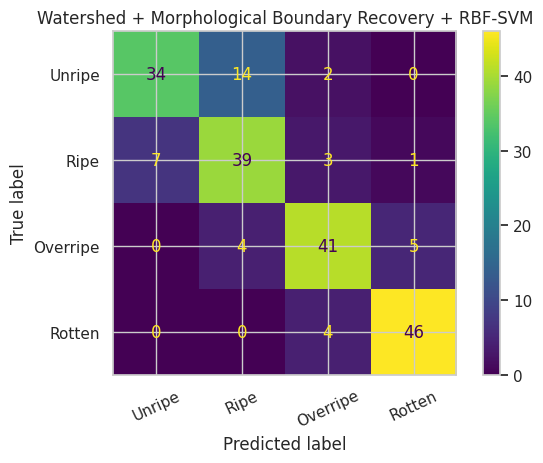

In [ ]:
watershed_recovery_cm = confusion_matrix(
    y_test,
    watershed_recovery_pred,
    labels=LABELS
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=watershed_recovery_cm,
    display_labels=LABELS
)

disp.plot(
    values_format="d",
    colorbar=True
)

plt.title(
    "Watershed + Morphological Boundary Recovery + RBF-SVM"
)

plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# PART E6.6 — FINAL COMPARISON
# ============================================================

comparison_recovery = pd.DataFrame([
    {
        "Method": "Original RGB Baseline",
        "Test Accuracy (%)":
            baseline_accuracy * 100,
        "Macro F1 (%)":
            baseline_macro_f1 * 100,
        "Correct / Total":
            f"{int(np.sum(baseline_pred == y_test))}/{len(y_test)}"
    },

    {
        "Method": "Marker-Controlled Watershed",
        "Test Accuracy (%)":
            watershed_accuracy * 100,
        "Macro F1 (%)":
            watershed_macro_f1 * 100,
        "Correct / Total":
            f"{int(np.sum(watershed_pred == y_test))}/{len(y_test)}"
    },

    {
        "Method":
            "Watershed + Boundary Recovery",
        "Test Accuracy (%)":
            watershed_recovery_accuracy * 100,
        "Macro F1 (%)":
            watershed_recovery_macro_f1 * 100,
        "Correct / Total":
            f"{int(np.sum(watershed_recovery_pred == y_test))}/{len(y_test)}"
    }
])

display(
    comparison_recovery.round(2)
)

,Method,Test Accuracy (%),Macro F1 (%),Correct / Total
0,Original RGB Baseline,83.5,83.44,167/200
1,Marker-Controlled Watershed,79.5,79.47,159/200
2,Watershed + Boundary Recovery,80.0,79.95,160/200


## Part E7 — VISUAL PREDICTION COMPARISON

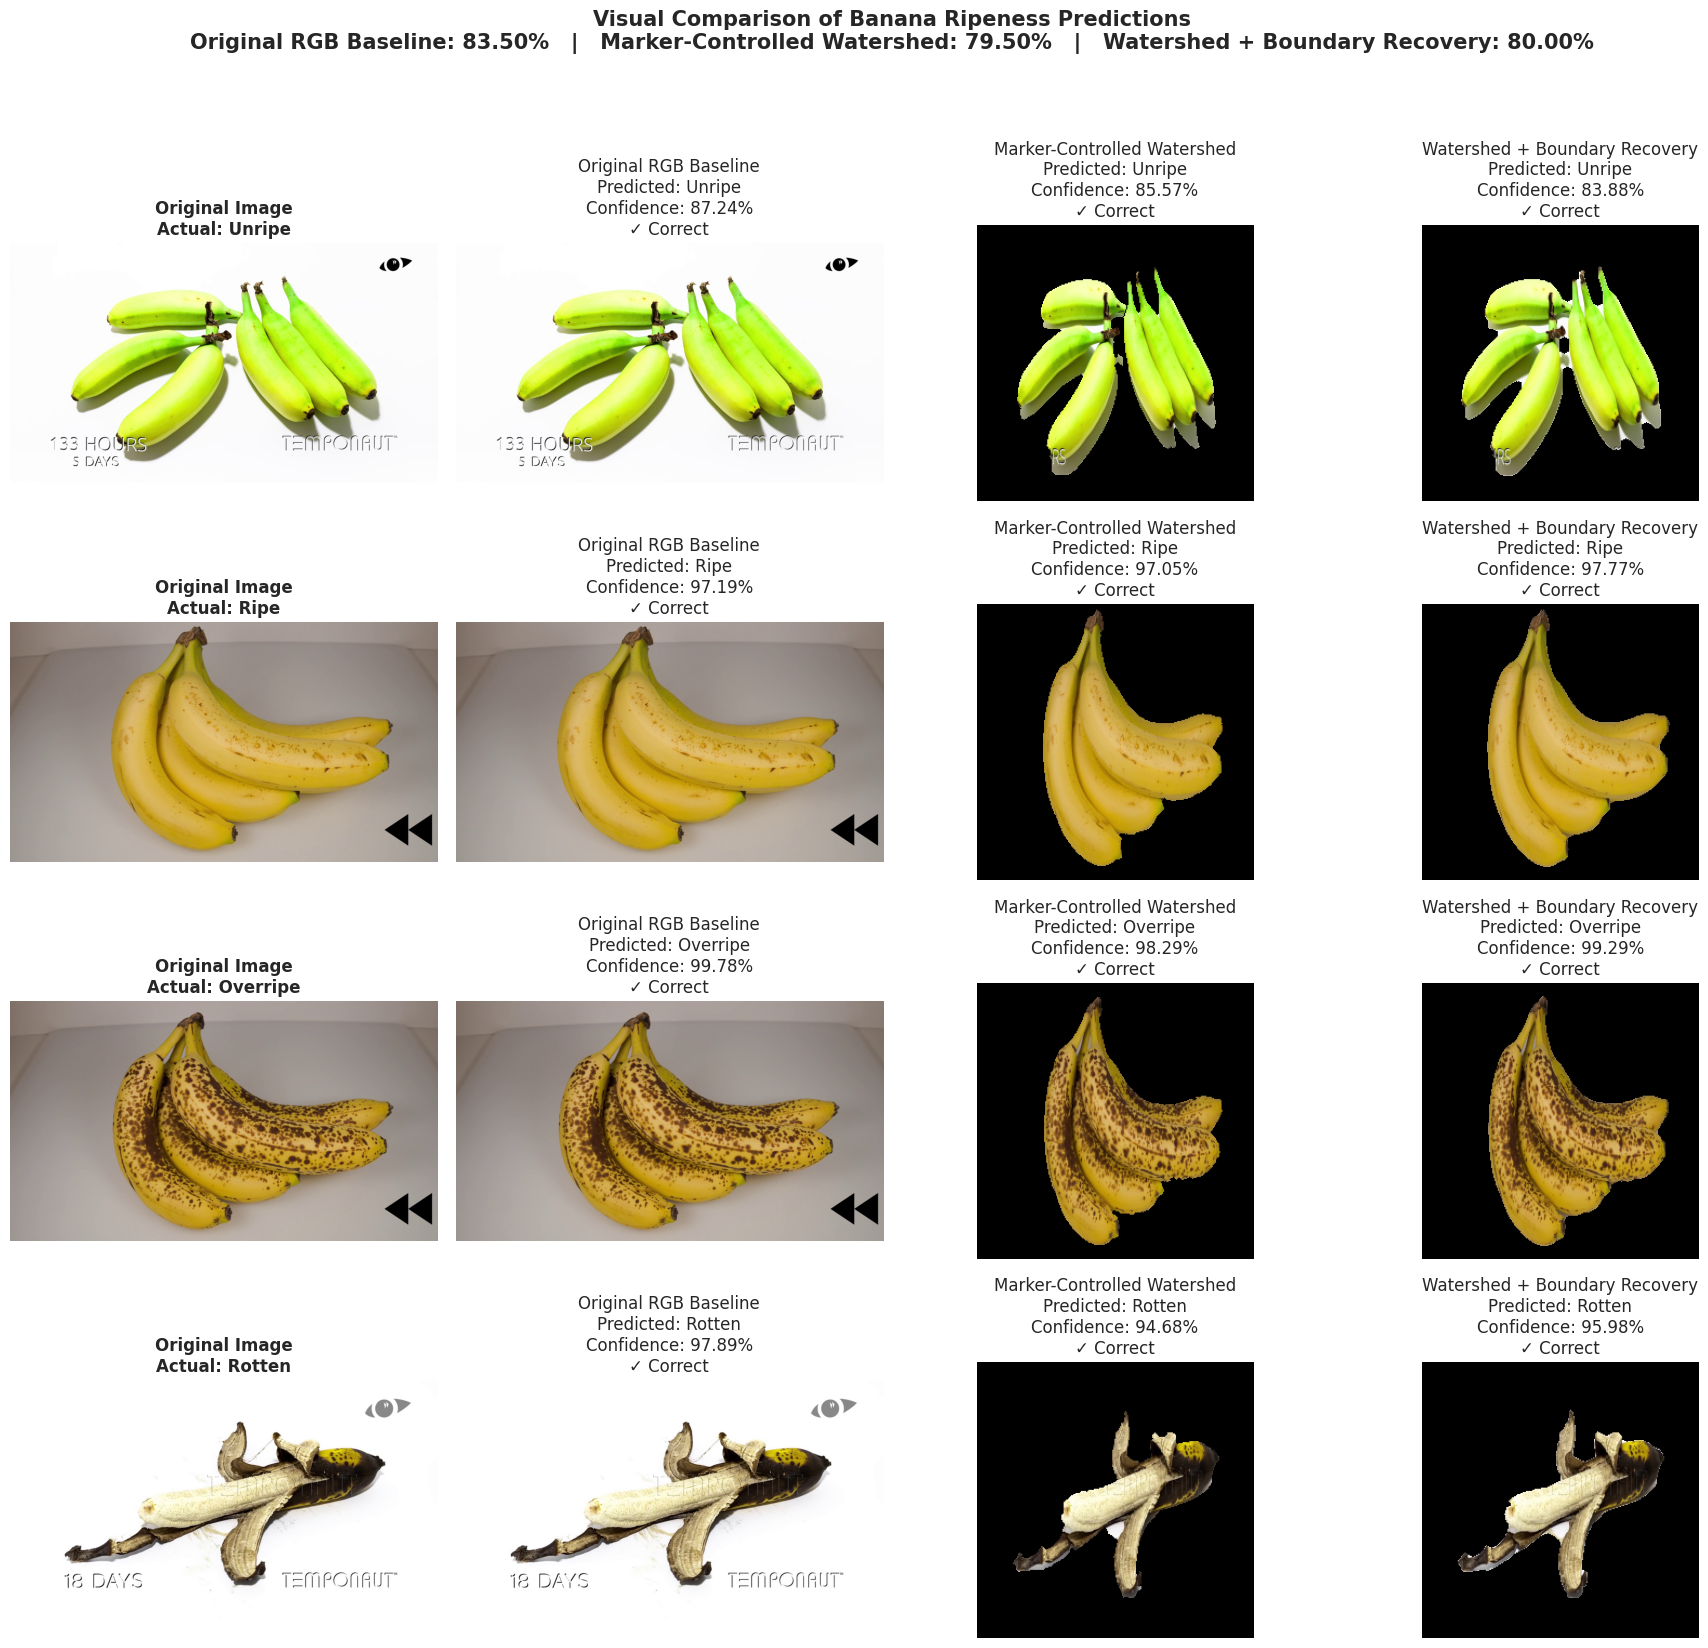

In [ ]:
# ============================================================
# PART E7 — VISUAL PREDICTION COMPARISON
# Original RGB vs Baseline vs Watershed + Boundary Recovery
# ============================================================

# Select one official test image from each class
manual_examples = (
    test_df
    .groupby("label", sort=False)
    .head(1)
    .set_index("label")
    .reindex(LABELS)
    .dropna()
    .reset_index()
)


def e7_predict(model, feature_vector):
    """Return predicted class and confidence."""
    row = feature_vector.reshape(1, -1)

    prediction = model.predict(row)[0]
    probabilities = model.predict_proba(row)[0]

    classes = list(
        model.named_steps["svm"].classes_
    )

    confidence = float(
        probabilities[
            classes.index(prediction)
        ]
    )

    return prediction, confidence


fig, axes = plt.subplots(
    len(manual_examples),
    4,
    figsize=(18, 4.2 * len(manual_examples))
)

if len(manual_examples) == 1:
    axes = np.expand_dims(axes, axis=0)


for row, sample in manual_examples.iterrows():

    path = sample["path"]
    actual = sample["label"]

    # ========================================================
    # 1. ORIGINAL RGB / BASELINE
    # ========================================================

    original_rgb = load_rgb(path)

    baseline_vector = rgb_pixel_vector(
        original_rgb
    )

    baseline_prediction, baseline_confidence = e7_predict(
        baseline_model,
        baseline_vector
    )

    # ========================================================
    # 2. MARKER-CONTROLLED WATERSHED
    # ========================================================

    watershed_result = apply_marker_controlled_watershed(
        path
    )

    watershed_rgb = watershed_result[
        "colour_cutout_rgb"
    ]

    watershed_vector = rgb_pixel_vector(
        watershed_rgb
    )

    watershed_prediction, watershed_confidence = e7_predict(
        watershed_model,
        watershed_vector
    )

    # ========================================================
    # 3. WATERSHED + MORPHOLOGICAL BOUNDARY RECOVERY
    # ========================================================

    recovery_result = apply_watershed_boundary_recovery(
        path
    )

    # Supports either naming used in the Eugene section
    if "recovered_cutout_rgb" in recovery_result:
        recovery_rgb = recovery_result[
            "recovered_cutout_rgb"
        ]
    else:
        recovery_rgb = recovery_result[
            "refined_cutout_rgb"
        ]

    recovery_vector = rgb_pixel_vector(
        recovery_rgb
    )

    recovery_prediction, recovery_confidence = e7_predict(
        watershed_recovery_model,
        recovery_vector
    )

    # ========================================================
    # CORRECT / INCORRECT INDICATORS
    # ========================================================

    baseline_status = (
        "✓ Correct"
        if baseline_prediction == actual
        else "✗ Incorrect"
    )

    watershed_status = (
        "✓ Correct"
        if watershed_prediction == actual
        else "✗ Incorrect"
    )

    recovery_status = (
        "✓ Correct"
        if recovery_prediction == actual
        else "✗ Incorrect"
    )

    # ========================================================
    # VISUALISATION
    # ========================================================

    # Column 1 — Original image
    axes[row, 0].imshow(
        original_rgb
    )

    axes[row, 0].set_title(
        f"Original Image\n"
        f"Actual: {actual.title()}",
        fontweight="bold"
    )

    # Column 2 — Baseline prediction
    axes[row, 1].imshow(
        original_rgb
    )

    axes[row, 1].set_title(
        f"Original RGB Baseline\n"
        f"Predicted: {baseline_prediction.title()}\n"
        f"Confidence: {baseline_confidence * 100:.2f}%\n"
        f"{baseline_status}"
    )

    # Column 3 — Watershed
    axes[row, 2].imshow(
        watershed_rgb
    )

    axes[row, 2].set_title(
        f"Marker-Controlled Watershed\n"
        f"Predicted: {watershed_prediction.title()}\n"
        f"Confidence: {watershed_confidence * 100:.2f}%\n"
        f"{watershed_status}"
    )

    # Column 4 — Watershed + Recovery
    axes[row, 3].imshow(
        recovery_rgb
    )

    axes[row, 3].set_title(
        f"Watershed + Boundary Recovery\n"
        f"Predicted: {recovery_prediction.title()}\n"
        f"Confidence: {recovery_confidence * 100:.2f}%\n"
        f"{recovery_status}"
    )

    for col in range(4):
        axes[row, col].axis("off")


# ============================================================
# OVERALL MODEL ACCURACY
# ============================================================

plt.suptitle(
    "Visual Comparison of Banana Ripeness Predictions\n"
    f"Original RGB Baseline: {baseline_accuracy * 100:.2f}%   |   "
    f"Marker-Controlled Watershed: {watershed_accuracy * 100:.2f}%   |   "
    f"Watershed + Boundary Recovery: "
    f"{watershed_recovery_accuracy * 100:.2f}%",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout(
    rect=[0, 0, 1, 0.95]
)

plt.show()

# KH


## Part F1: Contrast Enhancement and Texture Analysis


In [ ]:
# ============================================================
# ALGORITHM 3 SETTINGS
# Contrast Enhancement and Texture Analysis
# (CLAHE & Thresholding)
# ============================================================

import cv2
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage.feature import local_binary_pattern, hog

from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support
)


LABELS = ["Unripe", "Ripe", "Overripe", "Rotten"]

FEATURE_SIZE = (64, 64)

CLAHE_CLIP_LIMIT = 2.0
CLAHE_GRID_SIZE = (8, 8)

LBP_RADIUS = 2
LBP_POINTS = 16

HOG_ORIENTATIONS = 9
HOG_PIXELS_PER_CELL = (16, 16)
HOG_CELLS_PER_BLOCK = (2, 2)


# image_index, train_df and test_df come from your Part A code
train_df = image_index[
    image_index["split"] == "train"
].copy()

test_df = image_index[
    image_index["split"] == "test"
].copy()

print("Training images:", len(train_df))
print("Testing images :", len(test_df))

Training images: 1000
Testing images : 200


In [ ]:
# ============================================================
# FEATURE EXTRACTION FUNCTIONS
# ============================================================

def apply_clahe(gray):
    """
    CLAHE contrast enhancement.
    """

    clahe = cv2.createCLAHE(
        clipLimit=CLAHE_CLIP_LIMIT,
        tileGridSize=CLAHE_GRID_SIZE
    )

    return clahe.apply(gray)


def apply_otsu(image):
    """
    Otsu thresholding.
    """

    threshold, binary = cv2.threshold(
        image,
        0,
        255,
        cv2.THRESH_BINARY + cv2.THRESH_OTSU
    )

    return binary, threshold


def morphological_cleanup(binary):
    """
    Remove small noise using opening and closing.
    """

    kernel = np.ones((3, 3), np.uint8)

    opening = cv2.morphologyEx(
        binary,
        cv2.MORPH_OPEN,
        kernel
    )

    closing = cv2.morphologyEx(
        opening,
        cv2.MORPH_CLOSE,
        kernel
    )

    return closing


def extract_lbp_features(gray):
    """
    Local Binary Pattern texture features.
    """

    lbp = local_binary_pattern(
        gray,
        LBP_POINTS,
        LBP_RADIUS,
        method="uniform"
    )

    bins = LBP_POINTS + 2

    histogram, _ = np.histogram(
        lbp.ravel(),
        bins=np.arange(bins + 1),
        range=(0, bins)
    )

    histogram = histogram.astype(np.float32)

    if histogram.sum() > 0:
        histogram /= histogram.sum()

    return histogram


def extract_hog_features(gray):
    """
    Histogram of Oriented Gradients features.
    """

    features = hog(
        gray,
        orientations=HOG_ORIENTATIONS,
        pixels_per_cell=HOG_PIXELS_PER_CELL,
        cells_per_block=HOG_CELLS_PER_BLOCK,
        block_norm="L2-Hys",
        feature_vector=True
    )

    return features.astype(np.float32)


def extract_intensity_features(gray):
    """
    Basic grayscale intensity statistics.
    """

    image = gray.astype(np.float32)

    return np.array([
        np.mean(image),
        np.std(image),
        np.min(image),
        np.max(image),
        np.median(image),
        np.percentile(image, 25),
        np.percentile(image, 75)
    ], dtype=np.float32)


def extract_foreground_ratio(mask):
    """
    Percentage of detected foreground.
    """

    ratio = np.mean(mask > 0)

    return np.array(
        [ratio],
        dtype=np.float32
    )


# ------------------------------------------------------------
# Version A - CLAHE Only
# ------------------------------------------------------------

def extract_version_a(path):

    _, mask, foreground = preprocess_image(path)

    gray = cv2.cvtColor(
        foreground,
        cv2.COLOR_BGR2GRAY
    )

    enhanced = apply_clahe(gray)

    enhanced = cv2.resize(
        enhanced,
        FEATURE_SIZE,
        interpolation=cv2.INTER_AREA
    )

    enhanced = enhanced.astype(
        np.float32
    ) / 255.0

    return enhanced.flatten()


# ------------------------------------------------------------
# Version B - Hybrid
# CLAHE + Otsu + Morphology + LBP + HOG + Statistics
# ------------------------------------------------------------

def extract_version_b(path):

    _, mask, foreground = preprocess_image(path)

    gray = cv2.cvtColor(
        foreground,
        cv2.COLOR_BGR2GRAY
    )

    # CLAHE
    enhanced = apply_clahe(gray)

    # Otsu
    binary, _ = apply_otsu(enhanced)

    # Morphology
    cleaned = morphological_cleanup(binary)

    # Resize for texture extraction
    texture_image = cv2.resize(
        enhanced,
        FEATURE_SIZE,
        interpolation=cv2.INTER_AREA
    )

    # LBP
    lbp_features = extract_lbp_features(
        texture_image
    )

    # HOG
    hog_features = extract_hog_features(
        texture_image
    )

    # Intensity statistics
    intensity_features = extract_intensity_features(
        texture_image
    )

    # Foreground ratio
    foreground_features = extract_foreground_ratio(
        mask
    )

    # Otsu binary ratio
    binary_features = np.array([
        np.mean(cleaned > 0)
    ], dtype=np.float32)

    return np.concatenate([
        lbp_features,
        hog_features,
        intensity_features,
        foreground_features,
        binary_features
    ])

### Output review


PREPROCESSING OUTPUT REVIEW


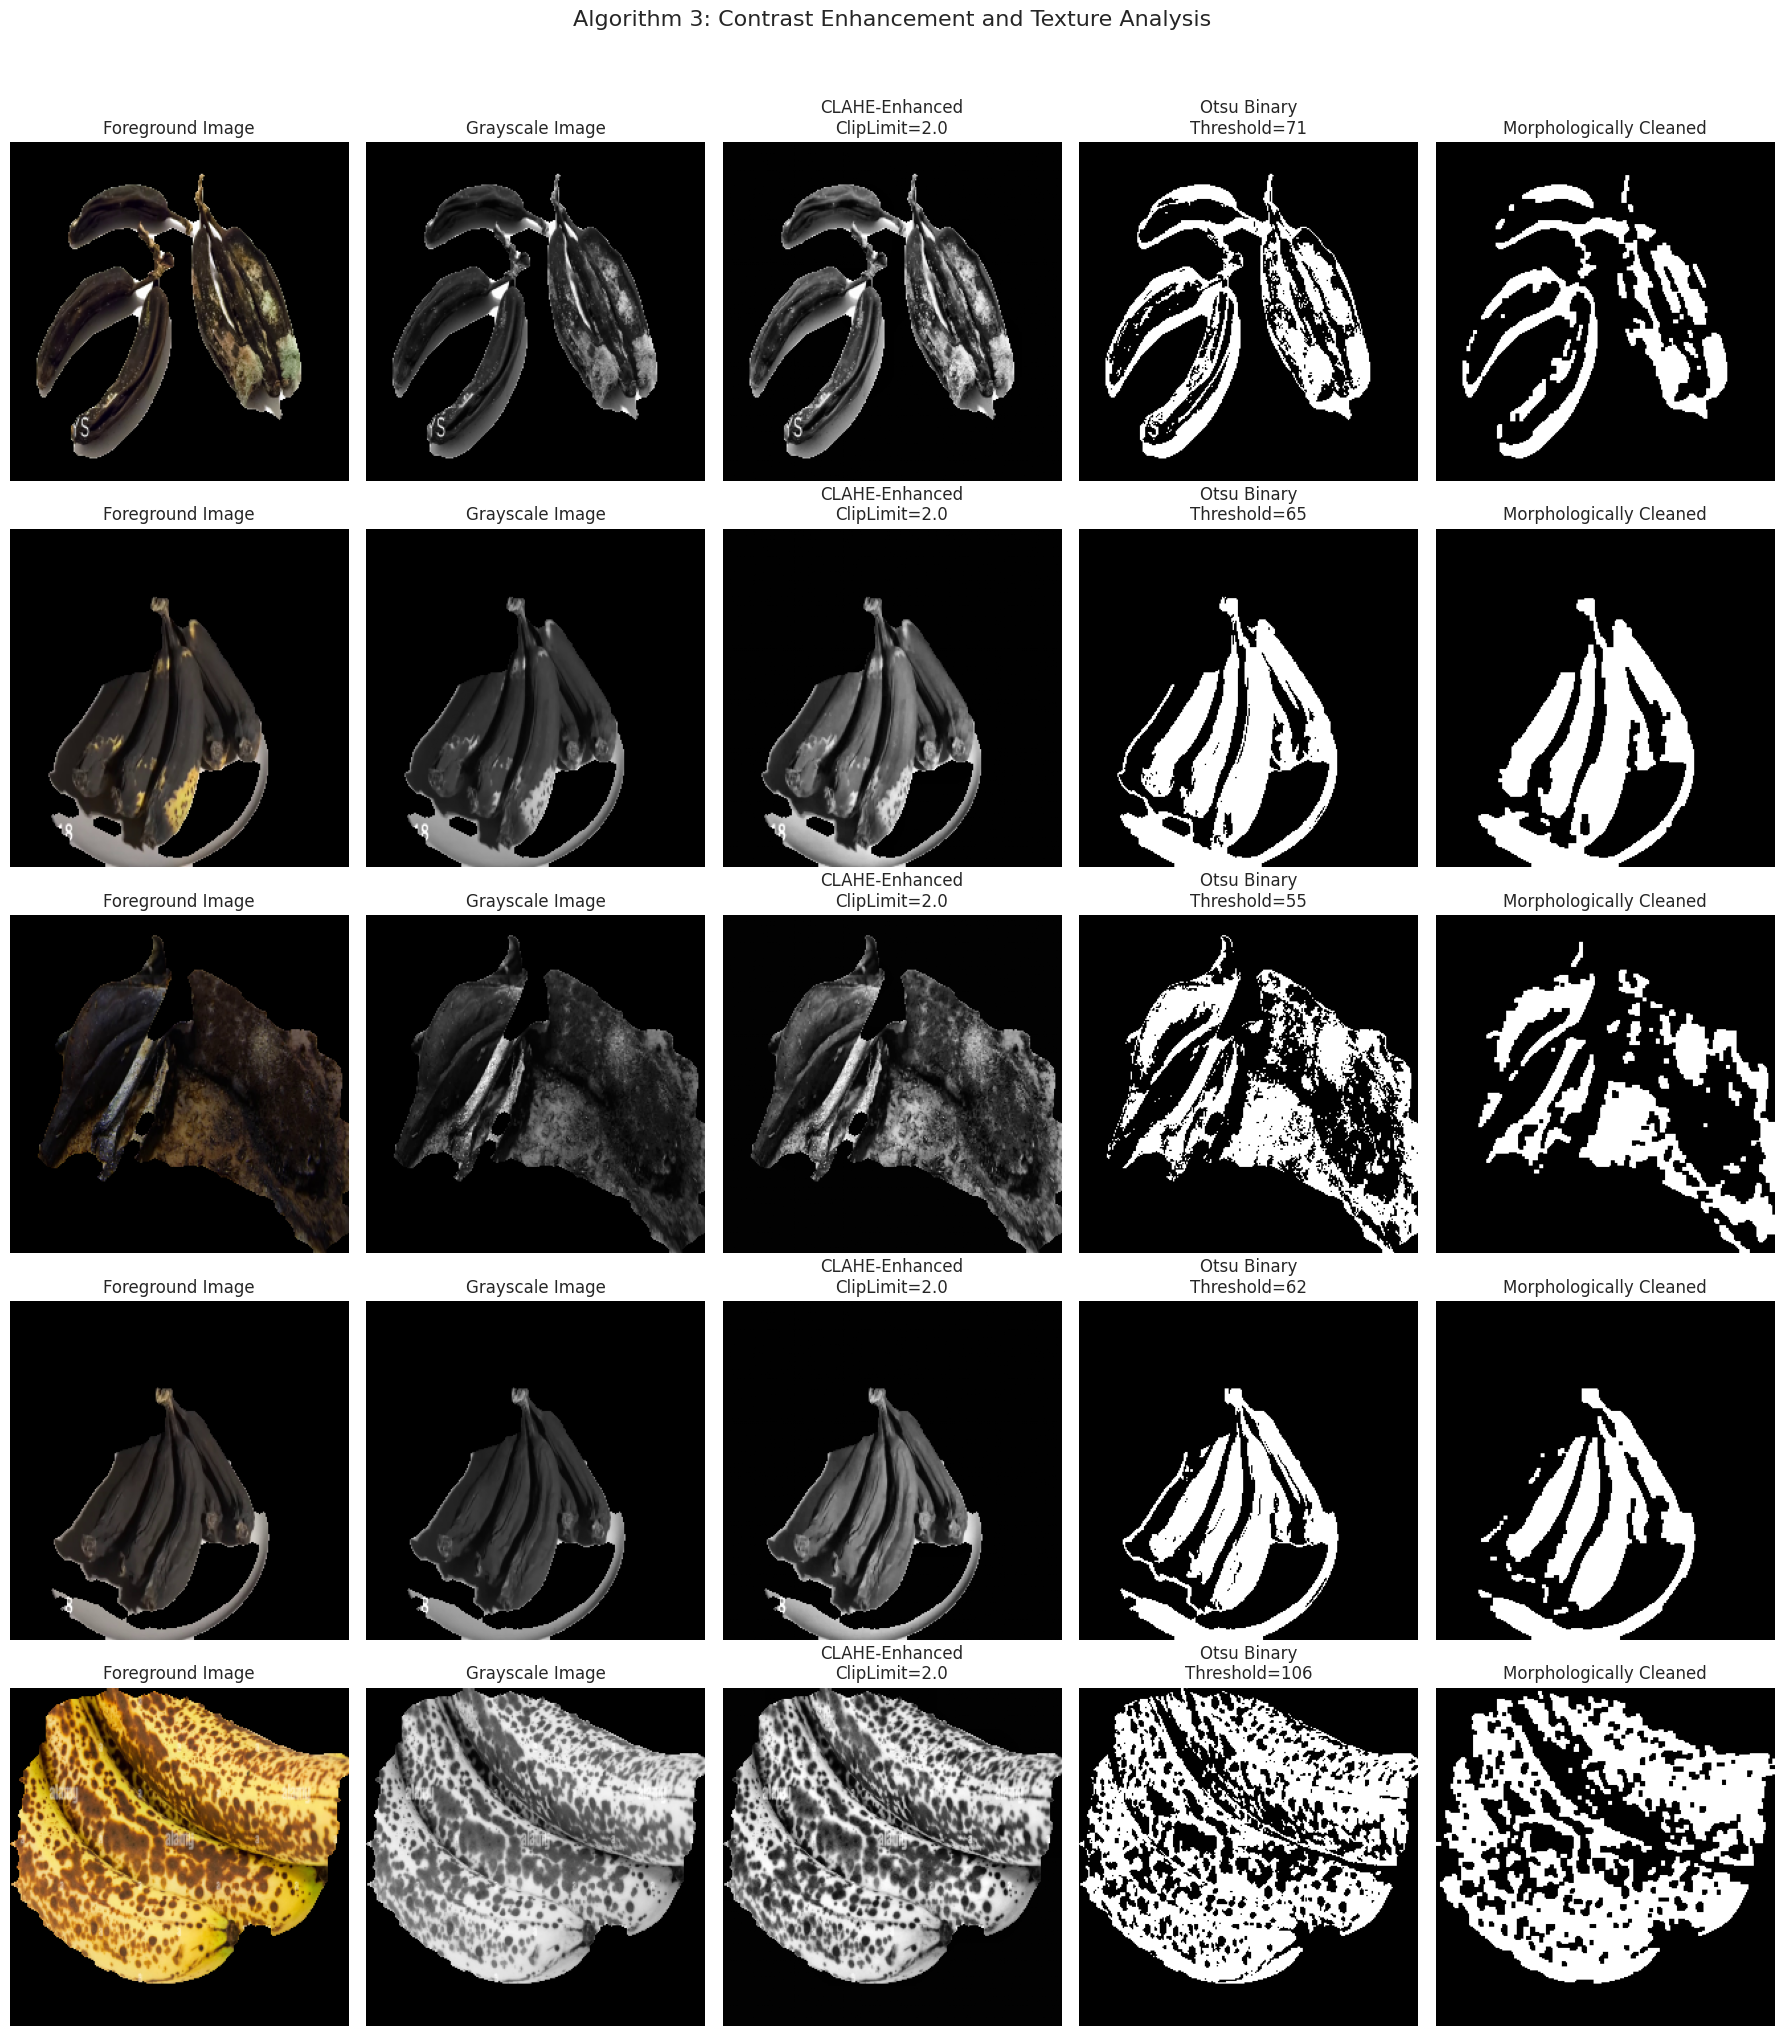

In [ ]:
# ============================================================
# PREPROCESSING OUTPUT REVIEW
# Foreground -> Grayscale -> CLAHE -> Otsu -> Morphology
# ============================================================

def review_preprocessing(
    dataframe,
    number_of_images=5,
    random_state=42
):
    """
    Display preprocessing results for multiple images.

    Stages:
    1. Foreground image
    2. Grayscale image
    3. CLAHE-enhanced image
    4. Otsu binary image
    5. Morphologically cleaned image
    """

    # Select random images
    sample_df = dataframe.sample(
        n=min(number_of_images, len(dataframe)),
        random_state=random_state
    ).reset_index(drop=True)

    fig, axes = plt.subplots(
        len(sample_df),
        5,
        figsize=(18, 4 * len(sample_df))
    )

    # Make axes 2D when only one image is selected
    if len(sample_df) == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, (_, row) in enumerate(sample_df.iterrows()):

        path = row["path"]
        label = row["label"]

        try:
            # ------------------------------------------------
            # Common Part A preprocessing
            # ------------------------------------------------
            _, mask, foreground = preprocess_image(path)

            # ------------------------------------------------
            # 1. Grayscale
            # ------------------------------------------------
            gray = cv2.cvtColor(
                foreground,
                cv2.COLOR_BGR2GRAY
            )

            # ------------------------------------------------
            # 2. CLAHE
            # ------------------------------------------------
            enhanced = apply_clahe(gray)

            # ------------------------------------------------
            # 3. Otsu Thresholding
            # ------------------------------------------------
            binary, threshold = apply_otsu(enhanced)

            # ------------------------------------------------
            # 4. Morphological Cleanup
            # ------------------------------------------------
            cleaned = morphological_cleanup(binary)

            # ------------------------------------------------
            # Display images
            # ------------------------------------------------

            # Foreground
            axes[i, 0].imshow(
                cv2.cvtColor(
                    foreground,
                    cv2.COLOR_BGR2RGB
                )
            )
            axes[i, 0].set_title("Foreground Image")

            # Grayscale
            axes[i, 1].imshow(
                gray,
                cmap="gray"
            )
            axes[i, 1].set_title("Grayscale Image")

            # CLAHE
            axes[i, 2].imshow(
                enhanced,
                cmap="gray"
            )
            axes[i, 2].set_title(
                f"CLAHE-Enhanced\nClipLimit={CLAHE_CLIP_LIMIT}"
            )

            # Otsu
            axes[i, 3].imshow(
                binary,
                cmap="gray"
            )
            axes[i, 3].set_title(
                f"Otsu Binary\nThreshold={threshold:.0f}"
            )

            # Morphology
            axes[i, 4].imshow(
                cleaned,
                cmap="gray"
            )
            axes[i, 4].set_title(
                "Morphologically Cleaned"
            )

            # Label and filename
            filename = path.split("/")[-1]

            axes[i, 0].set_ylabel(
                f"{label}\n{filename}",
                fontsize=10
            )

        except Exception as e:

            print(
                f"Review skipped: {path}"
            )
            print(
                f"Reason: {e}"
            )

            for j in range(5):
                axes[i, j].axis("off")

        # Remove axes
        for j in range(5):
            axes[i, j].axis("off")

    plt.suptitle(
        "Algorithm 3: Contrast Enhancement and Texture Analysis",
        fontsize=16,
        y=1.02
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# RUN PREPROCESSING REVIEW
# ============================================================

print("\n" + "=" * 70)
print("PREPROCESSING OUTPUT REVIEW")
print("=" * 70)

review_preprocessing(
    train_df,
    number_of_images=5,
    random_state=42
)

## Part F2: SVM Training & Evaluation

In [ ]:
# ============================================================
# SVM TRAINING AND EVALUATION
# ============================================================

def extract_dataset_features(dataframe, feature_function):

    features = []
    labels = []
    paths = []

    start = time.time()

    for _, row in dataframe.iterrows():

        try:

            feature = feature_function(
                row["path"]
            )

            features.append(feature)
            labels.append(row["label"])
            paths.append(row["path"])

        except Exception as e:

            print(
                f"Skipped: {row['path']}"
            )
            print(
                f"Reason: {e}"
            )

    elapsed = time.time() - start

    return (
        np.vstack(features),
        np.array(labels),
        paths,
        elapsed
    )


def create_svm():

    return Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "svm",
            SVC(
                kernel="rbf",
                C=10,
                gamma="scale"
            )
        )
    ])


def train_and_evaluate(
    X_train,
    y_train,
    X_test,
    y_test,
    version_name
):

    model = create_svm()

    # SVM training
    start = time.time()

    model.fit(
        X_train,
        y_train
    )

    training_time = time.time() - start

    # Training accuracy
    train_pred = model.predict(
        X_train
    )

    train_accuracy = accuracy_score(
        y_train,
        train_pred
    )

    # Testing
    start = time.time()

    test_pred = model.predict(
        X_test
    )

    prediction_time = time.time() - start

    test_accuracy = accuracy_score(
        y_test,
        test_pred
    )

    misclassified = np.sum(
        y_test != test_pred
    )

    cm = confusion_matrix(
        y_test,
        test_pred,
        labels=LABELS
    )

    report = classification_report(
        y_test,
        test_pred,
        labels=LABELS,
        target_names=LABELS,
        digits=4,
        zero_division=0
    )

    svm_model = model.named_steps["svm"]

    print("\n" + "=" * 60)
    print(version_name)
    print("=" * 60)

    print(
        f"Training Accuracy : "
        f"{train_accuracy * 100:.2f}%"
    )

    print(
        f"Testing Accuracy  : "
        f"{test_accuracy * 100:.2f}%"
    )

    print(
        f"SVM Training Time : "
        f"{training_time:.4f} seconds"
    )

    print(
        f"Average Prediction: "
        f"{prediction_time / len(X_test):.6f} sec/image"
    )

    print(
        f"Misclassified      : "
        f"{misclassified}"
    )

    print(
        f"Support Vectors    : "
        f"{svm_model.support_vectors_.shape[0]}"
    )

    print("\nClassification Report:")
    print(report)

    return {
        "model": model,
        "predictions": test_pred,
        "train_accuracy": train_accuracy,
        "test_accuracy": test_accuracy,
        "training_time": training_time,
        "prediction_time": prediction_time,
        "average_prediction_time":
            prediction_time / len(X_test),
        "misclassified": misclassified,
        "confusion_matrix": cm,
        "report": report
    }

In [ ]:
# ============================================================
# RUN VERSION A AND VERSION B
# ============================================================

# ------------------------------------------------------------
# VERSION A - CLAHE ONLY
# ------------------------------------------------------------

print("\n" + "#" * 60)
print("VERSION A - CLAHE ONLY")
print("#" * 60)

X_train_A, y_train_A, train_paths_A, extract_A_train = \
    extract_dataset_features(
        train_df,
        extract_version_a
    )

X_test_A, y_test_A, test_paths_A, extract_A_test = \
    extract_dataset_features(
        test_df,
        extract_version_a
    )

print(
    "Feature dimensions:",
    X_train_A.shape[1]
)

results_A = train_and_evaluate(
    X_train_A,
    y_train_A,
    X_test_A,
    y_test_A,
    "Version A - CLAHE Only"
)


# ------------------------------------------------------------
# VERSION B - HYBRID
# ------------------------------------------------------------

print("\n" + "#" * 60)
print("VERSION B - HYBRID")
print("#" * 60)

X_train_B, y_train_B, train_paths_B, extract_B_train = \
    extract_dataset_features(
        train_df,
        extract_version_b
    )

X_test_B, y_test_B, test_paths_B, extract_B_test = \
    extract_dataset_features(
        test_df,
        extract_version_b
    )

print(
    "Feature dimensions:",
    X_train_B.shape[1]
)

results_B = train_and_evaluate(
    X_train_B,
    y_train_B,
    X_test_B,
    y_test_B,
    "Version B - Hybrid"
)


############################################################
VERSION A - CLAHE ONLY
############################################################
Feature dimensions: 4096

Version A - CLAHE Only
Training Accuracy : 98.10%
Testing Accuracy  : 76.00%
SVM Training Time : 1.9470 seconds
Average Prediction: 0.003202 sec/image
Misclassified      : 48
Support Vectors    : 657

Classification Report:
              precision    recall  f1-score   support

      Unripe     0.6957    0.6400    0.6667        50
        Ripe     0.6140    0.7000    0.6542        50
    Overripe     0.8889    0.8000    0.8421        50
      Rotten     0.8654    0.9000    0.8824        50

    accuracy                         0.7600       200
   macro avg     0.7660    0.7600    0.7613       200
weighted avg     0.7660    0.7600    0.7613       200


############################################################
VERSION B - HYBRID
############################################################
Feature dimensions: 351

Ve

## Part F3: Results comparison & Graphs



FINAL COMPARISON
                      Metric  CLAHE Only      Hybrid
             Training Images 1000.000000 1000.000000
              Testing Images  200.000000  200.000000
          Feature Dimensions 4096.000000  351.000000
       Training Accuracy (%)   98.100000   99.300000
        Testing Accuracy (%)   76.000000   83.500000
       SVM Training Time (s)    1.947012    0.203365
Average Prediction (s/image)    0.003202    0.000290
        Misclassified Images   48.000000   33.000000


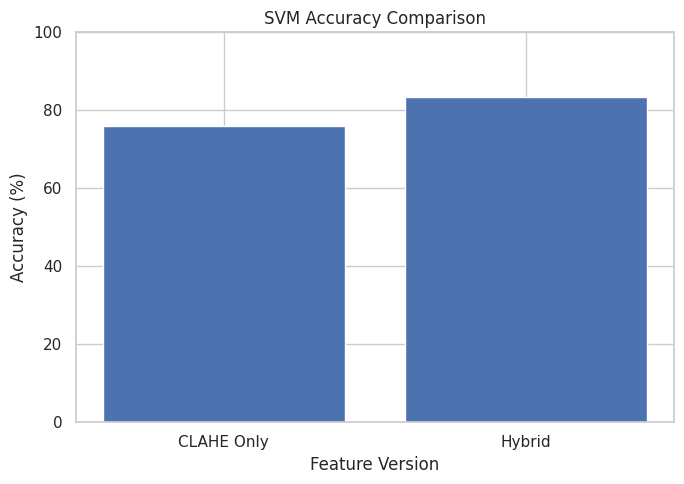

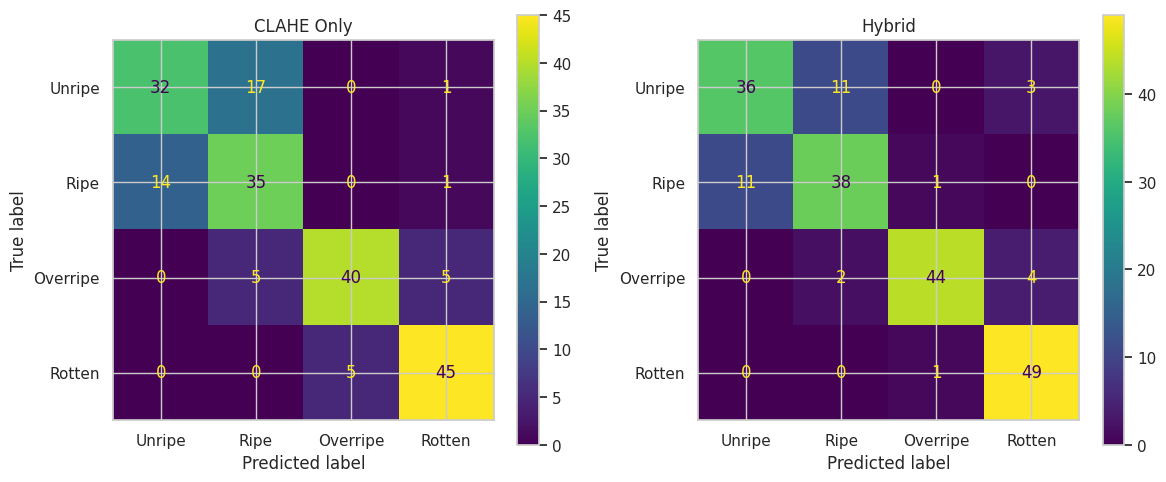


CLAHE Only Metrics:
      Class  Precision  Recall      F1
0    Unripe     0.6957    0.64  0.6667
1      Ripe     0.6140    0.70  0.6542
2  Overripe     0.8889    0.80  0.8421
3    Rotten     0.8654    0.90  0.8824

Hybrid Metrics:
      Class  Precision  Recall      F1
0    Unripe     0.7660    0.72  0.7423
1      Ripe     0.7451    0.76  0.7525
2  Overripe     0.9565    0.88  0.9167
3    Rotten     0.8750    0.98  0.9245


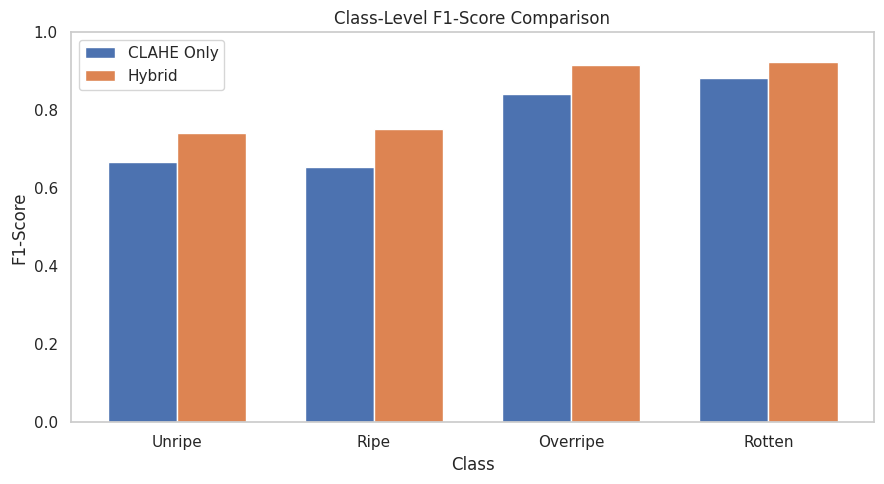

In [ ]:
# ============================================================
# RESULTS COMPARISON AND GRAPHS
# ============================================================

# ------------------------------------------------------------
# Overall comparison
# ------------------------------------------------------------

comparison = pd.DataFrame({
    "Metric": [
        "Training Images",
        "Testing Images",
        "Feature Dimensions",
        "Training Accuracy (%)",
        "Testing Accuracy (%)",
        "SVM Training Time (s)",
        "Average Prediction (s/image)",
        "Misclassified Images"
    ],

    "CLAHE Only": [
        len(X_train_A),
        len(X_test_A),
        X_train_A.shape[1],
        results_A["train_accuracy"] * 100,
        results_A["test_accuracy"] * 100,
        results_A["training_time"],
        results_A["average_prediction_time"],
        results_A["misclassified"]
    ],

    "Hybrid": [
        len(X_train_B),
        len(X_test_B),
        X_train_B.shape[1],
        results_B["train_accuracy"] * 100,
        results_B["test_accuracy"] * 100,
        results_B["training_time"],
        results_B["average_prediction_time"],
        results_B["misclassified"]
    ]
})

print("\n" + "=" * 60)
print("FINAL COMPARISON")
print("=" * 60)

print(
    comparison.to_string(index=False)
)


# ------------------------------------------------------------
# Accuracy graph
# ------------------------------------------------------------

versions = [
    "CLAHE Only",
    "Hybrid"
]

accuracies = [
    results_A["test_accuracy"] * 100,
    results_B["test_accuracy"] * 100
]

plt.figure(figsize=(7, 5))

plt.bar(
    versions,
    accuracies
)

plt.ylabel("Accuracy (%)")
plt.xlabel("Feature Version")
plt.title("SVM Accuracy Comparison")
plt.ylim(0, 100)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Confusion matrices
# ------------------------------------------------------------

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

ConfusionMatrixDisplay(
    results_A["confusion_matrix"],
    display_labels=LABELS
).plot(
    ax=axes[0],
    values_format="d"
)

axes[0].set_title(
    "CLAHE Only"
)

ConfusionMatrixDisplay(
    results_B["confusion_matrix"],
    display_labels=LABELS
).plot(
    ax=axes[1],
    values_format="d"
)

axes[1].set_title(
    "Hybrid"
)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Class-level F1 comparison
# ------------------------------------------------------------

def get_metrics(y_true, y_pred):

    precision, recall, f1, support = \
        precision_recall_fscore_support(
            y_true,
            y_pred,
            labels=LABELS,
            zero_division=0
        )

    return pd.DataFrame({
        "Class": LABELS,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })


metrics_A = get_metrics(
    y_test_A,
    results_A["predictions"]
)

metrics_B = get_metrics(
    y_test_B,
    results_B["predictions"]
)

print("\nCLAHE Only Metrics:")
print(metrics_A.round(4))

print("\nHybrid Metrics:")
print(metrics_B.round(4))


plt.figure(figsize=(9, 5))

x = np.arange(len(LABELS))
width = 0.35

plt.bar(
    x - width / 2,
    metrics_A["F1"],
    width,
    label="CLAHE Only"
)

plt.bar(
    x + width / 2,
    metrics_B["F1"],
    width,
    label="Hybrid"
)

plt.xticks(
    x,
    LABELS
)

plt.xlabel("Class")
plt.ylabel("F1-Score")
plt.title("Class-Level F1-Score Comparison")

plt.ylim(0, 1)
plt.legend()

plt.grid(False)
plt.tight_layout()
plt.show()

### Sample output and actual vs predicted


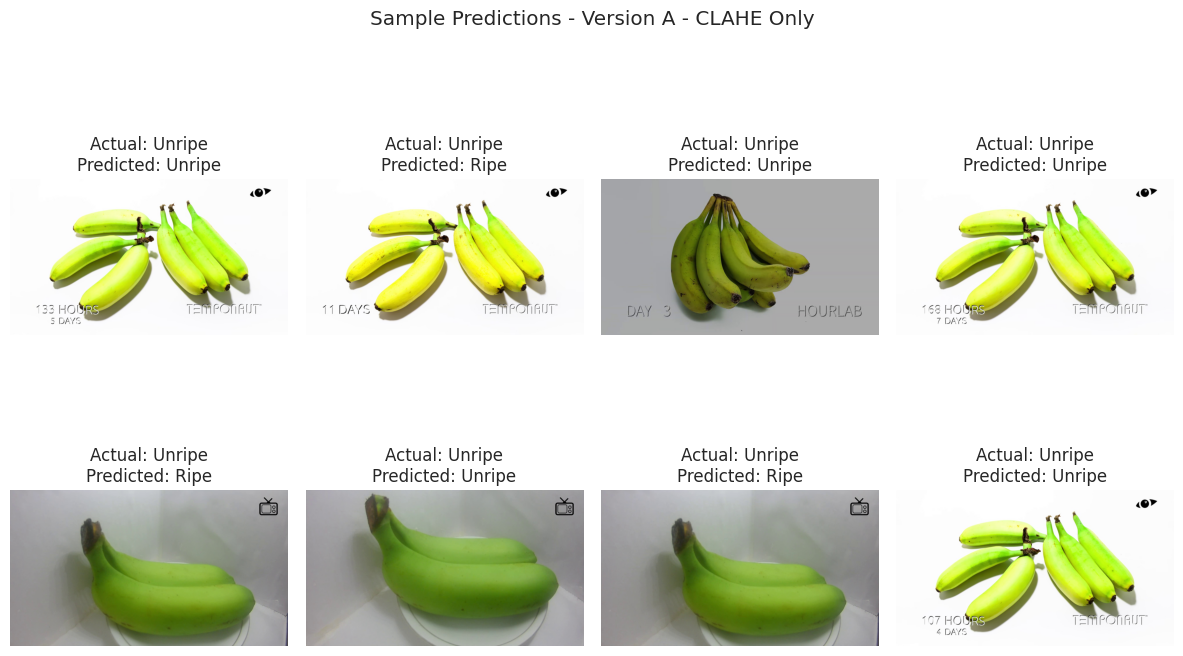

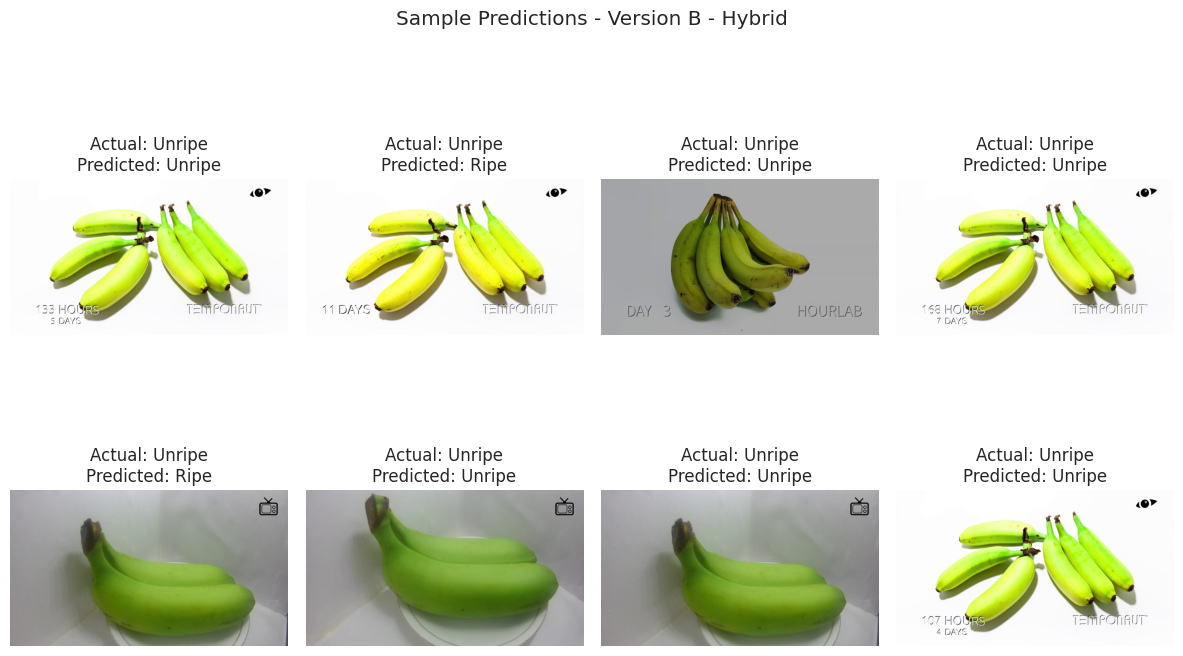

In [ ]:
# ============================================================
# SAMPLE OUTPUT AND ACTUAL VS PREDICTED
# ============================================================

def show_sample_predictions(
    dataframe,
    paths,
    y_true,
    y_pred,
    version_name,
    num_samples=8
):
    """
    Display sample images with actual and predicted labels.
    Uses the existing trained SVM predictions.
    """

    # Select first few samples
    num_samples = min(
        num_samples,
        len(paths)
    )

    # Find corresponding dataframe rows
    sample_paths = paths[:num_samples]

    plt.figure(
        figsize=(12, 8)
    )

    for i, path in enumerate(sample_paths):

        image = cv2.imread(path)

        if image is None:
            continue

        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        plt.subplot(
            2,
            4,
            i + 1
        )

        plt.imshow(image)

        actual = y_true[i]
        predicted = y_pred[i]

        if actual == predicted:
            title = (
                f"Actual: {actual}\n"
                f"Predicted: {predicted}"
            )
        else:
            title = (
                f"Actual: {actual}\n"
                f"Predicted: {predicted}"
            )

        plt.title(title)
        plt.axis("off")

    plt.suptitle(
        f"Sample Predictions - {version_name}"
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# SHOW VERSION A SAMPLE OUTPUT
# ============================================================

show_sample_predictions(
    test_df,
    test_paths_A,
    y_test_A,
    results_A["predictions"],
    "Version A - CLAHE Only",
    num_samples=8
)


# ============================================================
# SHOW VERSION B SAMPLE OUTPUT
# ============================================================

show_sample_predictions(
    test_df,
    test_paths_B,
    y_test_B,
    results_B["predictions"],
    "Version B - Hybrid",
    num_samples=8
)

### DIRECT COMPARISON: ACTUAL VS VERSION A VS VERSION B

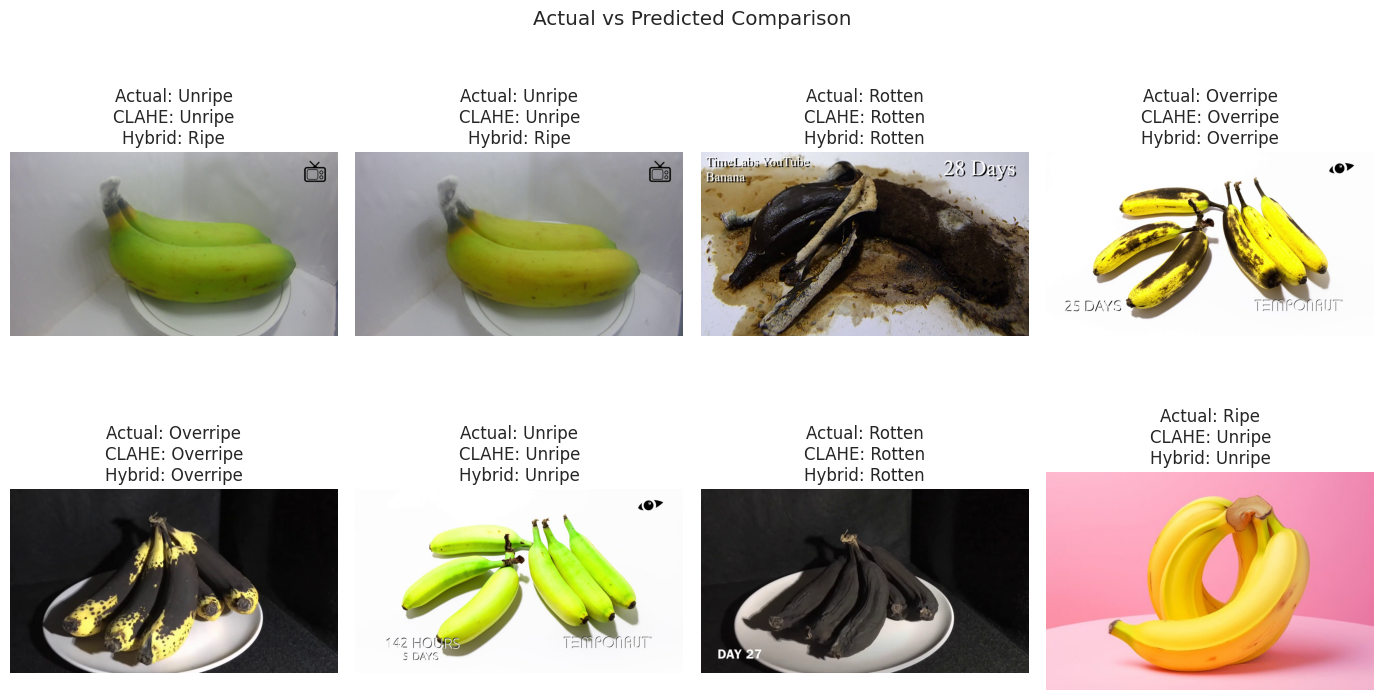

In [ ]:
# ============================================================
# ACTUAL VS CLAHE VS HYBRID
# ============================================================

def show_comparison_samples(
    paths,
    actual,
    prediction_A,
    prediction_B,
    num_samples=8
):
    """
    Randomly select the same test images and compare
    CLAHE and Hybrid predictions.
    """

    num_samples = min(
        num_samples,
        len(paths)
    )

    selected_indices = np.random.choice(
        len(paths),
        size=num_samples,
        replace=False
    )

    plt.figure(figsize=(14, 8))

    for plot_num, index in enumerate(selected_indices):

        image = cv2.imread(paths[index])

        if image is None:
            continue

        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        actual_label = actual[index]
        clahe_label = prediction_A[index]
        hybrid_label = prediction_B[index]

        plt.subplot(2, 4, plot_num + 1)

        plt.imshow(image)

        plt.title(
            f"Actual: {actual_label}\n"
            f"CLAHE: {clahe_label}\n"
            f"Hybrid: {hybrid_label}"
        )

        plt.axis("off")

    plt.suptitle(
        "Actual vs Predicted Comparison"
    )

    plt.tight_layout()
    plt.show()



show_comparison_samples(
    test_paths_A,
    y_test_A,
    results_A["predictions"],
    results_B["predictions"],
    num_samples=8
)

### Output of Misclassified Banana Images

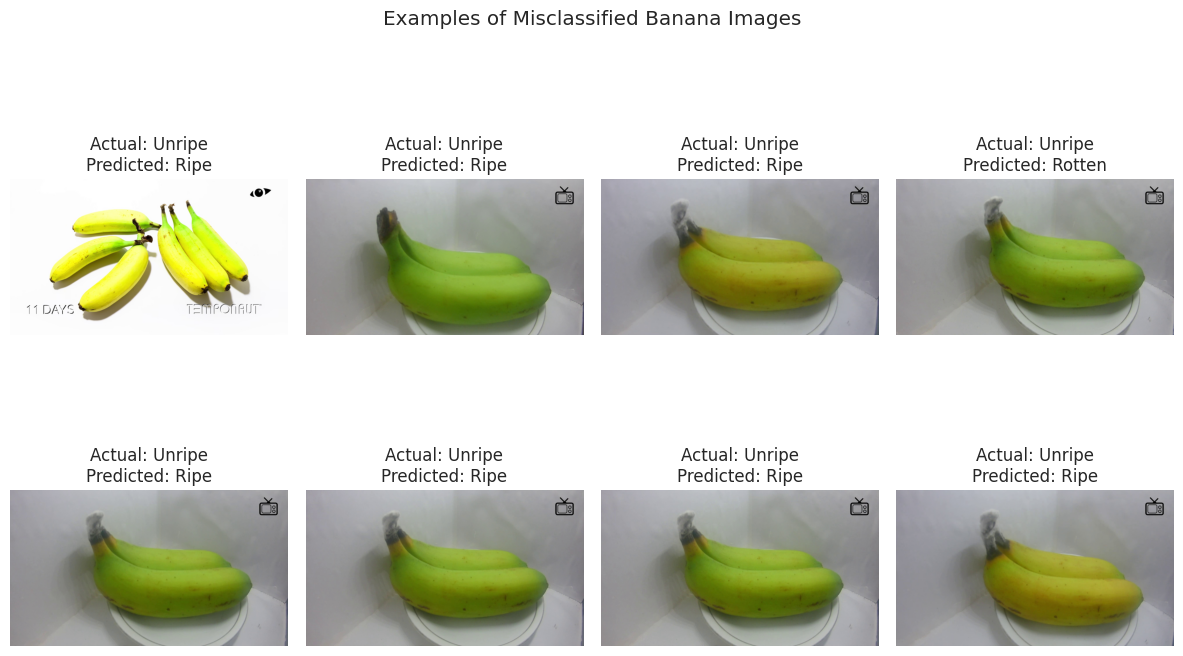

In [ ]:
# ============================================================
# MISCLASSIFIED BANANA IMAGES - VERSION B
# ============================================================

def show_misclassified_images(
    paths,
    y_true,
    y_pred,
    num_images=8
):

    wrong_indices = np.where(
        y_true != y_pred
    )[0]

    if len(wrong_indices) == 0:

        print("No misclassified images found.")
        return

    num_images = min(
        num_images,
        len(wrong_indices)
    )

    selected = wrong_indices[:num_images]

    plt.figure(
        figsize=(12, 8)
    )

    for i, index in enumerate(selected):

        image = cv2.imread(
            paths[index]
        )

        if image is None:
            continue

        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        plt.subplot(
            2,
            4,
            i + 1
        )

        plt.imshow(image)

        plt.title(
            f"Actual: {y_true[index]}\n"
            f"Predicted: {y_pred[index]}"
        )

        plt.axis("off")

    plt.suptitle(
        "Examples of Misclassified Banana Images"
    )

    plt.tight_layout()
    plt.show()


show_misclassified_images(
    test_paths_B,
    y_test_B,
    results_B["predictions"],
    num_images=8
)

### Correct / Incorrect Comparison

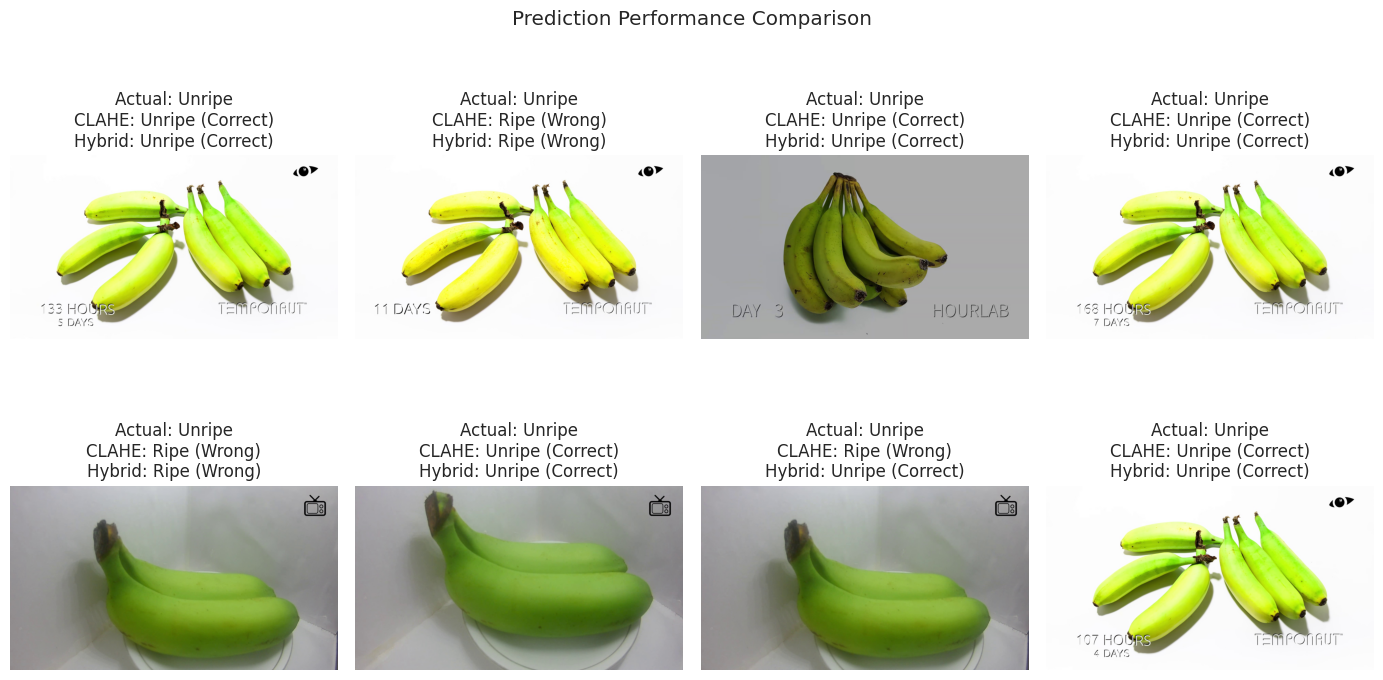

In [ ]:
# ============================================================
# CORRECT / INCORRECT COMPARISON
# ============================================================

def show_prediction_comparison_status(
    paths,
    actual,
    prediction_A,
    prediction_B,
    num_samples=8
):

    num_samples = min(
        num_samples,
        len(paths)
    )

    plt.figure(
        figsize=(14, 8)
    )

    for i in range(num_samples):

        image = cv2.imread(
            paths[i]
        )

        if image is None:
            continue

        image = cv2.cvtColor(
            image,
            cv2.COLOR_BGR2RGB
        )

        a_correct = (
            actual[i] == prediction_A[i]
        )

        b_correct = (
            actual[i] == prediction_B[i]
        )

        plt.subplot(
            2,
            4,
            i + 1
        )

        plt.imshow(image)

        status_A = "Correct" if a_correct else "Wrong"
        status_B = "Correct" if b_correct else "Wrong"

        plt.title(
            f"Actual: {actual[i]}\n"
            f"CLAHE: {prediction_A[i]} ({status_A})\n"
            f"Hybrid: {prediction_B[i]} ({status_B})"
        )

        plt.axis("off")

    plt.suptitle(
        "Prediction Performance Comparison"
    )

    plt.tight_layout()
    plt.show()


show_prediction_comparison_status(
    test_paths_A,
    y_test_A,
    results_A["predictions"],
    results_B["predictions"],
    num_samples=8
)

In [ ]:
# ============================================================
# SAMPLE PREDICTION TABLE
# ============================================================

import os

sample_comparison = pd.DataFrame({
    "Image": [
        os.path.basename(path)
        for path in test_paths_A[:20]
    ],

    "Actual": y_test_A[:20],

    "CLAHE Prediction": results_A[
        "predictions"
    ][:20],

    "Hybrid Prediction": results_B[
        "predictions"
    ][:20]
})

sample_comparison[
    "CLAHE Correct"
] = (
    sample_comparison["Actual"]
    ==
    sample_comparison["CLAHE Prediction"]
)

sample_comparison[
    "Hybrid Correct"
] = (
    sample_comparison["Actual"]
    ==
    sample_comparison["Hybrid Prediction"]
)

print(
    sample_comparison.to_string(
        index=False
    )
)

             Image Actual CLAHE Prediction Hybrid Prediction  CLAHE Correct  Hybrid Correct
frame_0030 (2).png Unripe           Unripe            Unripe           True            True
frame_0048 (2).png Unripe             Ripe              Ripe          False           False
    frame_0040.png Unripe           Unripe            Unripe           True            True
frame_0034 (2).png Unripe           Unripe            Unripe           True            True
    frame_0030.png Unripe             Ripe              Ripe          False           False
    frame_0024.png Unripe           Unripe            Unripe           True            True
    frame_0029.png Unripe             Ripe            Unripe          False            True
frame_0027 (2).png Unripe           Unripe            Unripe           True            True
frame_0044 (2).png Unripe             Ripe            Unripe          False            True
    frame_0044.png Unripe           Unripe              Ripe           True     

# Streamlit

In [ ]:
# ============================================================
# FINAL MODEL SELECTION + JOBLIB EXPORT
# Compare 3 Algorithms → Select ONE Best → Save ONE Model
# ============================================================

import joblib
import sklearn

from sklearn.utils.validation import check_is_fitted
from google.colab import files as colab_files


# ============================================================
# 1. CHECK THAT ALL 3 ALGORITHMS HAVE BEEN TRAINED
# ============================================================

required_variables = [
    # Algorithm 1
    "search",
    "accuracy",
    "feature_columns",

    # Algorithm 2
    "watershed_recovery_model",
    "watershed_recovery_accuracy",

    # Algorithm 3
    "results_B",
]

missing_variables = [
    name
    for name in required_variables
    if name not in globals()
]

if missing_variables:
    raise RuntimeError(
        "The following training results are missing:\n"
        + "\n".join(
            f"- {name}"
            for name in missing_variables
        )
        + "\n\nRun the corresponding training cells first."
    )


# ============================================================
# 2. GET THE THREE TRAINED SVM MODELS
# ============================================================

# ------------------------------------------------------------
# Algorithm 1 — Adaptive HSV + CIELAB
# GridSearchCV already refitted the best estimator
# ------------------------------------------------------------

adaptive_model = search.best_estimator_

adaptive_accuracy = float(
    accuracy
)


# ------------------------------------------------------------
# Algorithm 2 — Watershed + Morphological Boundary Recovery
# ------------------------------------------------------------

recovery_model = watershed_recovery_model

recovery_accuracy = float(
    watershed_recovery_accuracy
)


# ------------------------------------------------------------
# Algorithm 3 — Contrast Enhancement + Texture
# Use Version B because it is the COMPLETE Hybrid algorithm:
# CLAHE + Otsu + Morphology + LBP + HOG + Statistics
# ------------------------------------------------------------

if (
    not isinstance(results_B, dict)
    or "model" not in results_B
    or "test_accuracy" not in results_B
):
    raise RuntimeError(
        "results_B is incomplete. "
        "Run Algorithm 3 Version B training first."
    )

contrast_model = results_B[
    "model"
]

contrast_accuracy = float(
    results_B["test_accuracy"]
)


# ============================================================
# 3. VERIFY THAT ALL THREE SVM MODELS ARE ACTUALLY FITTED
# ============================================================

models_to_check = {
    "Adaptive HSV + CIELAB":
        adaptive_model,

    "Watershed + Boundary Recovery":
        recovery_model,

    "Contrast Enhancement + Texture":
        contrast_model,
}

for model_name, model in models_to_check.items():

    try:
        check_is_fitted(model)

    except Exception as e:

        raise RuntimeError(
            f"{model_name} model is not trained yet.\n"
            f"Run its SVM training cell before exporting."
        ) from e


# ============================================================
# 4. CREATE THE 3-ALGORITHM COMPARISON
# ============================================================

algorithm_candidates = {

    "Adaptive HSV + CIELAB": {
        "accuracy":
            adaptive_accuracy,

        "model":
            adaptive_model,

        "feature_extractor":
            "adaptive_hsv_lab",

        "feature_columns":
            list(feature_columns),
    },

    "Watershed + Morphological Boundary Recovery": {
        "accuracy":
            recovery_accuracy,

        "model":
            recovery_model,

        "feature_extractor":
            "watershed_boundary_recovery",

        "feature_columns":
            None,
    },

    "Contrast Enhancement + Texture Analysis": {
        "accuracy":
            contrast_accuracy,

        "model":
            contrast_model,

        "feature_extractor":
            "contrast_hybrid",

        "feature_columns":
            None,
    },
}


# ============================================================
# 5. PRINT COMPARISON
# ============================================================

print("\n" + "=" * 75)
print("FINAL ALGORITHM COMPARISON")
print("=" * 75)

sorted_candidates = sorted(
    algorithm_candidates.items(),
    key=lambda item:
        item[1]["accuracy"],
    reverse=True
)

for rank, (name, information) in enumerate(
    sorted_candidates,
    start=1
):

    print(
        f"{rank}. "
        f"{name:<45} "
        f"{information['accuracy'] * 100:.2f}%"
    )

print("=" * 75)


# ============================================================
# 6. AUTOMATICALLY SELECT ONLY THE BEST ALGORITHM
# ============================================================

best_algorithm_name = max(
    algorithm_candidates,
    key=lambda name:
        algorithm_candidates[name]["accuracy"]
)

best_algorithm = algorithm_candidates[
    best_algorithm_name
]

best_model = best_algorithm[
    "model"
]

best_accuracy = best_algorithm[
    "accuracy"
]

best_feature_extractor = best_algorithm[
    "feature_extractor"
]


# ============================================================
# 7. DISPLAY WINNER CLEARLY
# ============================================================

print("\n" + "#" * 75)
print("BEST ALGORITHM SELECTED FOR STREAMLIT")
print("#" * 75)

print(
    "Selected Algorithm :",
    best_algorithm_name
)

print(
    f"Test Accuracy      : "
    f"{best_accuracy * 100:.2f}%"
)

print(
    "Feature Extractor  :",
    best_feature_extractor
)

print(
    "SVM Model          :",
    type(
        best_model.named_steps["svm"]
    ).__name__
)

print(
    "Classes            :",
    list(
        best_model.named_steps[
            "svm"
        ].classes_
    )
)

print("\nIMPORTANT:")
print(
    "Only this ONE winning model "
    "will be saved into the Joblib file."
)

print("#" * 75)


# ============================================================
# 8. SAVE PARAMETERS NEEDED BY THE FUTURE STREAMLIT APP
# ============================================================

selected_parameters = {}


# ------------------------------------------------------------
# Adaptive HSV + CIELAB
# ------------------------------------------------------------

if (
    best_feature_extractor
    == "adaptive_hsv_lab"
):

    selected_parameters = {
        "feature_columns":
            list(feature_columns)
    }


# ------------------------------------------------------------
# Watershed + Boundary Recovery
# ------------------------------------------------------------

elif (
    best_feature_extractor
    == "watershed_boundary_recovery"
):

    selected_parameters = {

        "shared_image_size":
            256,

        "svm_image_size":
            (64, 64),

        "watershed_foreground_distance_ratio":
            WATERSHED_FOREGROUND_DISTANCE_RATIO,

        "watershed_marker_kernel_size":
            WATERSHED_MARKER_KERNEL_SIZE,

        "watershed_envelope_dilation_iterations":
            WATERSHED_ENVELOPE_DILATION_ITERATIONS,

        "recovery_kernel_size":
            RECOVERY_KERNEL_SIZE,

        "recovery_close_iterations":
            RECOVERY_CLOSE_ITERATIONS,

        "recovery_dilate_iterations":
            RECOVERY_DILATE_ITERATIONS,
    }


# ------------------------------------------------------------
# Contrast Enhancement + Texture
# ------------------------------------------------------------

elif (
    best_feature_extractor
    == "contrast_hybrid"
):

    selected_parameters = {

        "feature_size":
            FEATURE_SIZE,

        "clahe_clip_limit":
            CLAHE_CLIP_LIMIT,

        "clahe_grid_size":
            CLAHE_GRID_SIZE,

        "lbp_radius":
            LBP_RADIUS,

        "lbp_points":
            LBP_POINTS,

        "hog_orientations":
            HOG_ORIENTATIONS,

        "hog_pixels_per_cell":
            HOG_PIXELS_PER_CELL,

        "hog_cells_per_block":
            HOG_CELLS_PER_BLOCK,
    }


# ============================================================
# 9. CREATE ONE DEPLOYMENT BUNDLE
# ============================================================

deployment_bundle = {

    # --------------------------------------------------------
    # ONLY ONE TRAINED MODEL
    # --------------------------------------------------------
    "model":
        best_model,

    # --------------------------------------------------------
    # Tell Streamlit which ONE image-processing algorithm
    # must be used before model.predict()
    # --------------------------------------------------------
    "selected_algorithm":
        best_algorithm_name,

    "feature_extractor":
        best_feature_extractor,

    # --------------------------------------------------------
    # Performance
    # --------------------------------------------------------
    "test_accuracy":
        best_accuracy,

    # Store scores for display/debugging ONLY.
    # No other SVM models are saved.
    "algorithm_comparison": {
        name:
            information["accuracy"]

        for name, information
        in algorithm_candidates.items()
    },

    # --------------------------------------------------------
    # Classification labels
    # --------------------------------------------------------
    "classes":
        list(
            best_model
            .named_steps["svm"]
            .classes_
        ),

    # --------------------------------------------------------
    # Parameters needed to reproduce the winning feature
    # extraction in app.py
    # --------------------------------------------------------
    "parameters":
        selected_parameters,

    # --------------------------------------------------------
    # Version information
    # --------------------------------------------------------
    "sklearn_version":
        sklearn.__version__,
}


# ============================================================
# 10. SAVE JOBLIB
# ============================================================

JOBLIB_FILENAME = (
    "best_banana_ripeness_model.joblib"
)

joblib.dump(
    deployment_bundle,
    JOBLIB_FILENAME
)


# ============================================================
# 11. FINAL CONFIRMATION
# ============================================================

print("\n" + "=" * 75)
print("JOBLIB EXPORT COMPLETE")
print("=" * 75)

print(
    "File:",
    JOBLIB_FILENAME
)

print(
    "Algorithm inside Joblib:",
    deployment_bundle[
        "selected_algorithm"
    ]
)

print(
    f"Accuracy inside Joblib: "
    f"{deployment_bundle['test_accuracy'] * 100:.2f}%"
)

print(
    "Feature extraction mode:",
    deployment_bundle[
        "feature_extractor"
    ]
)

print("\nModels stored in Joblib: 1")
print("Other candidate SVM models stored: NO")

print("=" * 75)


# ============================================================
# 12. DOWNLOAD JOBLIB FROM COLAB
# ============================================================

colab_files.download(
    JOBLIB_FILENAME
)


FINAL ALGORITHM COMPARISON
1. Adaptive HSV + CIELAB                         91.50%
2. Contrast Enhancement + Texture Analysis       83.50%
3. Watershed + Morphological Boundary Recovery   80.00%

###########################################################################
BEST ALGORITHM SELECTED FOR STREAMLIT
###########################################################################
Selected Algorithm : Adaptive HSV + CIELAB
Test Accuracy      : 91.50%
Feature Extractor  : adaptive_hsv_lab
SVM Model          : SVC
Classes            : ['Overripe', 'Ripe', 'Rotten', 'Unripe']

IMPORTANT:
Only this ONE winning model will be saved into the Joblib file.
###########################################################################

JOBLIB EXPORT COMPLETE
File: best_banana_ripeness_model.joblib
Algorithm inside Joblib: Adaptive HSV + CIELAB
Accuracy inside Joblib: 91.50%
Feature extraction mode: adaptive_hsv_lab

Models stored in Joblib: 1
Other candidate SVM models stored: NO


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>